# 34 · Diffusion 전방 과정: 잡음을 조금씩 더하고 그 잡음을 맞히기

**이번 질문:** 33번의 $\sigma$ 사다리를 "시간 $t$에 따라 데이터를 서서히 지우는 과정"으로 바꾸면, 중간 단계를 다 거치지 않고 한 번에 $t$ 시점으로 갈 수 있을까요? 그때 신경망이 맞혀야 할 정답은 무엇이고, 그것이 32번의 score와 어떻게 같을까요?

33번은 잡음 크기 $\sigma$를 큰 값에서 작은 값으로 내려오며 score를 이어 붙였습니다. 이번에는 같은 생각을 **시간**으로 바꿔 씁니다. 걸음마다 데이터를 조금 줄이고 잡음을 조금 더하는 규칙 하나를 정하고, 그 규칙을 $t$번 이어 붙입니다.
그러면 놀랍게도 $t$번 반복한 결과가 닫힌식 Gaussian 하나가 되어 **한 줄로 건너뛸 수 있습니다.** 학습은 "더한 잡음 $\epsilon$을 맞히기"라는 평범한 회귀가 되고, 그 답이 32번의 score와 상수배로 이어집니다.
한 걸음과 한 번에 가기 → 되묻기(posterior) → 학습 타깃 세 가지 → 잡음 예측 신경망 → $t$마다 다른 손실 크기 순서로 갑니다. 되돌아오는 샘플링은 [35](35_diffusion_reverse.ipynb)에서 합니다.

- 준비물: [12](../02_연결/12_gaussian_information.ipynb) 2절의 Gaussian 로그 밀도와 1절의 $\epsilon\mapsto\mu+L\epsilon$, [23](23_latent_mixture_em.ipynb)의 혼합과 `mix_denoiser`, [32](32_score_matching.ipynb)·[33](33_ncsn.ipynb)의 score와 DSM, [03](../00_기초/03_perceptron_to_mlp.ipynb)·[04](../00_기초/04_optimizers.ipynb)의 MLP backward와 Adam, [09](../01_아키텍처/09_transformer.ipynb) 4절의 sinusoidal 표.
- 도착점: 닫힌식 $q(x_t\mid x_0)$와 posterior 계수, $\epsilon$ 타깃을 손계산·반복 시뮬레이션·격자 적분으로 검산하고, 혼합의 최적 denoiser를 정답지로 삼아 잡음 예측 신경망을 학습합니다.
- 다음 연결: [35 역과정](35_diffusion_reverse.ipynb)은 여기서 배운 $\hat\epsilon$으로 순수 잡음에서 $x_0$까지 $T$걸음 되돌아옵니다.

### 읽는 법

| 표시 | 뜻 | 어떻게 읽나 |
|---|---|---|
| 🔑 **핵심** | 수식·규칙·코드. 이 노트북이 가르치려는 것 | 남에게 설명할 수 있을 때까지 읽고, 코드를 가리고 다시 써 봅니다 |
| 🔍 **확인** | 검산 결과와 그림의 해석 | 실행해서 눈으로 보고 넘어갑니다. 외울 것은 없습니다 |
| 📎 **참고** | 배경 지식, 환경, 용어의 유래 | 처음 읽을 때는 건너뛰어도 됩니다 |
| ✏️ **연습** | 직접 바꿔 보는 문제 | 손으로 먼저 예상한 뒤 실행합니다 |

새 용어는 처음 나오는 자리에서 **용어** 상자로 한 줄씩 풀이합니다.

**이 노트북에서 반드시 가져갈 세 가지**

1. 한 걸음 $q(x_t\mid x_{t-1})=\mathcal N(\sqrt{1-\beta_t}\,x_{t-1},\ \beta_t I)$를 $t$번 이어 붙이면 $q(x_t\mid x_0)=\mathcal N(\sqrt{\bar\alpha_t}\,x_0,\ (1-\bar\alpha_t)I)$입니다. $\bar\alpha_t=\prod_{s\le t}(1-\beta_s)$이고, 코드로는 `np.sqrt(ab) * x0 + np.sqrt(1 - ab) * eps` 한 줄입니다.
2. 되묻기 $q(x_{t-1}\mid x_t,x_0)$도 Gaussian이고 평균은 $x_0$와 $x_t$의 가중합 $\tilde\mu_t=c_0(t)x_0+c_t(t)x_t$, 분산은 $\tilde\beta_t=\frac{1-\bar\alpha_{t-1}}{1-\bar\alpha_t}\beta_t\le\beta_t$입니다.
3. $x_t=\sqrt{\bar\alpha_t}x_0+\sqrt{1-\bar\alpha_t}\epsilon$이므로 $x_0$ 예측과 $\epsilon$ 예측은 한 줄로 서로 바뀌고, 최적 $\epsilon$ 예측은 score와 $\nabla_{x_t}\log q(x_t)=-\epsilon^*(x_t)/\sqrt{1-\bar\alpha_t}$로 이어집니다. 학습은 `np.mean(np.sum((eps_hat - eps) ** 2, axis=1))` 하나입니다.

[전체 학습 경로](../../docs/CURRICULUM.md) · [글 규칙](../../docs/WRITING.md) · [그림 설계](../../docs/DESIGN.md) · [그림 보조 코드](../../src/utils/diffusion_forward_plots.py)

In [1]:
# 준비 셀: 실행만 하고 넘어가도 됩니다.
# 1) 프로젝트 루트를 import 경로에 넣습니다. 노트북을 어느 폴더에서 열어도 src/를 찾기 위해서입니다.
import sys
from pathlib import Path
project_root = next(p for p in (Path.cwd(), *Path.cwd().parents)          # 현재 폴더부터 위로 올라가며
                    if (p / "src/utils/plotting.py").is_file())            # src/utils/plotting.py가 있는 첫 폴더를 고릅니다
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# 2) NumPy, 수치미분 도우미(1절부터: 중심차분 numerical_gradient와 상대오차 rel_error), 연습 검사 도우미, 데이터 로더, 이 노트북의 그림 함수(src/utils/diffusion_forward_plots.py)
import numpy as np
from src.utils import setup_plots
from src.utils.gradcheck import numerical_gradient, rel_error
from src.utils import run_check
from src.data.mnist import load_mnist, load_examples
from src.utils.diffusion_forward_plots import (
    plot_curves, plot_forward_band, plot_mixture_forward, plot_posterior_coefficients, plot_targets,
    plot_denoiser_blocks, plot_learned_eps, plot_eps_field_2d, plot_denoised_examples,
    plot_loss_by_t, plot_schedule_comparison,
)

# 3) 그림 설정. 배열 출력은 소수 4자리로 줄여 읽기 쉽게 합니다.
setup_plots()
np.set_printoptions(precision=4, suppress=True)
print("NumPy", np.__version__, "· diffusion 전방 과정 준비 완료")

NumPy 2.4.6 · diffusion 전방 과정 준비 완료


### 📎 이 노트북의 예시: 1차원 두 봉우리 혼합, 고정 예시 7, MNIST PCA-32 좌표

- **1차원 두 봉우리 혼합.** 23번부터 쓰는 공통 상황입니다. 비율 $\pi=(0.3,0.7)$, 평균 $\mu=(-2,2)$, 표준편차 $\sigma=(0.5,1)$인 두 Gaussian을 섞은 분포입니다. 잡음을 더한 뒤의 밀도·최적 복원이 모두 닫힌식이라, 신경망이 배운 결과의 **정답지**로 씁니다. 2차원 판도 함께 둡니다.
- **고정 예시 7.** 00번부터 쓴 MNIST 예시 10장 중 7입니다. 시간 $t$가 커질수록 이 한 장이 어떻게 지워지는지 눈으로 봅니다. 학습에는 쓰지 않습니다.
- **MNIST PCA-32 좌표.** 앞 5,000장을 11번 3절의 고유분해로 32차원 좌표로 줄인 것입니다. 784차원 그대로 학습하면 느리고, 32개 좌표만으로도 숫자 모양이 남습니다. 4절에서 이 좌표 위의 잡음 예측 신경망을 학습합니다.

> **용어**
>
> - **혼합(mixture) 분포**: 성분 $k$를 비율 $\pi_k$로 고른 뒤 그 Gaussian에서 점을 뽑는 분포. 밀도는 $p(x)=\sum_k\pi_k\mathcal N(x;\mu_k,\sigma_k^2)$입니다 (23번 1절).
> - **책임확률(responsibility)** $r_k(x)=p(z=k\mid x)$: 점 $x$가 성분 $k$에서 왔을 확률. 로그 항의 softmax입니다 (23번 2절).
> - **최적 복원(denoiser)** $\mathbb E[x_0\mid \tilde x]$: 잡음이 섞인 점 $\tilde x$를 보고 원래 점을 되짚는 조건부 평균. 혼합이면 분산이 $\sigma_k^2+\sigma^2$로 커진 책임확률과 성분별 조건부 평균의 가중합입니다 (23번 5절). 코드에서는 `mix_denoiser(x_noisy, sigma)`.
> - **MNIST**: 28×28 흑백 손글씨 숫자 이미지 데이터셋. 여기서는 잡음이 실제 그림에서 어떻게 보이는지, 그리고 32차원 좌표에서 학습이 되는지를 보려고 씁니다.

아래 네 셀은 실행만 하고 넘어가도 됩니다. 혼합 함수는 23번의 정의를 그대로 짧게 다시 쓴 것이고, `sigma` 인자를 주면 잡음이 섞인 뒤의 분포가 됩니다 (32번 3절).

> **코드**
>
> - `x[:, None]`: `(N,)`을 `(N, 1)`로 세워 `(2,)`짜리 성분 배열과 브로드캐스팅. 결과는 `(N, 2)` = 점마다 성분 두 개.
> - `terms.max(axis=1, keepdims=True)`: 행마다 최댓값을 `(N, 1)`로 남겨 빼기 쉽게 합니다. 지수가 넘치지 않게 하는 02번 8절의 안정화입니다.
> - `rng.choice(2, size=n, p=MIX_PI)`: 0 또는 1을 확률 `MIX_PI`로 n번 뽑습니다. 잠재 성분 $z$를 먼저 뽑는 ancestral sampling (23번 5절).
> - `np.linalg.solve(C, d.T).T`: 관측마다 $C^{-1}d$를 한 번에 (12번 2절). `np.linalg.slogdet(C)[1]`은 $\log\det C$.

In [2]:
MIX_PI = np.array([0.3, 0.7])                                        # (2,): 성분 비율 π_k
MIX_MU = np.array([-2.0, 2.0])                                       # (2,): 성분 평균 μ_k
MIX_SIGMA = np.array([0.5, 1.0])                                     # (2,): 성분 표준편차 σ_k
MIX2_PI = np.array([0.4, 0.6])                                       # (2,): 2차원 혼합의 비율
MIX2_MU = np.array([[-2.0, 0.0], [2.0, 1.0]])                        # (2, 2): 성분 평균 (행 = 성분)
MIX2_COV = np.array([[[0.6, 0.2], [0.2, 0.5]], [[0.4, -0.1], [-0.1, 0.8]]])   # (2, 2, 2): 성분 공분산 Σ_k
print("1차원 π, μ, σ:", MIX_PI, MIX_MU, MIX_SIGMA, "· 2차원 평균", MIX2_MU.tolist())

1차원 π, μ, σ: [0.3 0.7] [-2.  2.] [0.5 1. ] · 2차원 평균 [[-2.0, 0.0], [2.0, 1.0]]


In [3]:
def mix_log_terms(x, sigma=0.0):
    """성분별 log π_k + log N(x; μ_k, σ_k² + σ²). sigma 는 나중에 더하는 잡음의 표준편차(0이면 원래 혼합). x: (N,) → (N, 2)."""
    variances = MIX_SIGMA ** 2 + sigma ** 2                          # (2,): 성분 분산
    squared = (x[:, None] - MIX_MU) ** 2 / variances                 # (N, 2): 표준화한 제곱 거리
    return np.log(MIX_PI) - 0.5 * (np.log(2 * np.pi * variances) + squared)


def mix_logpdf(x, sigma=0.0):
    """23번 1절: log p(x) = logsumexp_k [log π_k + log N(x; μ_k, σ_k²)]. x: (N,) → (N,)."""
    terms = mix_log_terms(x, sigma)
    biggest = terms.max(axis=1, keepdims=True)                       # (N, 1): 행마다 최댓값 (안정화)
    return (biggest + np.log(np.exp(terms - biggest).sum(axis=1, keepdims=True)))[:, 0]


def mix_responsibility(x, sigma=0.0):
    """23번 2절: r_k(x) = softmax_k 로그 항. x: (N,) → (N, 2), 행 합 1."""
    terms = mix_log_terms(x, sigma)
    shifted = np.exp(terms - terms.max(axis=1, keepdims=True))       # (N, 2)
    return shifted / shifted.sum(axis=1, keepdims=True)


def mix_sample(n, rng):
    """23번 5절 ancestral sampling: z ~ π 를 뽑고 x ~ N(μ_z, σ_z²). n: 개수 → (n,)."""
    z = rng.choice(2, size=n, p=MIX_PI)                              # (n,): 성분 번호
    return MIX_MU[z] + MIX_SIGMA[z] * rng.normal(size=n)


def mix_denoiser(x_noisy, sigma):
    """23번 5절: 잡음 뒤 최적 복원 E[x₀ | x̃] = Σ_k r_k^σ(x̃) [μ_k + σ_k²/(σ_k² + σ²) (x̃ − μ_k)]. x_noisy: (N,) → (N,)."""
    r = mix_responsibility(x_noisy, sigma)                           # (N, 2): 분산 σ_k² + σ² 의 책임확률
    shrink = MIX_SIGMA ** 2 / (MIX_SIGMA ** 2 + sigma ** 2)          # (2,): 성분별로 x̃ 를 μ_k 쪽으로 당기는 비율
    return np.sum(r * (MIX_MU + shrink * (x_noisy[:, None] - MIX_MU)), axis=1)

In [4]:
def mix2_log_terms(X, sigma=0.0):
    """2차원 성분별 log π_k + log N(x; μ_k, Σ_k + σ²I). X: (N, 2) → (N, 2)."""
    terms = np.zeros((len(X), 2))
    for k in range(2):
        covariance = MIX2_COV[k] + sigma ** 2 * np.eye(2)            # (2, 2): 잡음을 더한 공분산
        difference = X - MIX2_MU[k]                                  # (N, 2): x − μ_k
        squared = np.sum(difference * np.linalg.solve(covariance, difference.T).T, axis=1)   # (N,): (x−μ)ᵀ Σ⁻¹ (x−μ)
        terms[:, k] = np.log(MIX2_PI[k]) - 0.5 * (2 * np.log(2 * np.pi) + np.linalg.slogdet(covariance)[1] + squared)
    return terms


def mix2_logpdf(X, sigma=0.0):
    """2차원 혼합의 log p(x) (23번 1절). X: (N, 2) → (N,)."""
    terms = mix2_log_terms(X, sigma)
    biggest = terms.max(axis=1, keepdims=True)
    return (biggest + np.log(np.exp(terms - biggest).sum(axis=1, keepdims=True)))[:, 0]


def mix2_responsibility(X, sigma=0.0):
    """2차원 혼합의 책임확률 (23번 2절). X: (N, 2) → (N, 2)."""
    terms = mix2_log_terms(X, sigma)
    shifted = np.exp(terms - terms.max(axis=1, keepdims=True))
    return shifted / shifted.sum(axis=1, keepdims=True)

In [5]:
def mix2_sample(n, rng):
    """2차원 ancestral sampling: z ~ π, x = μ_z + L_z ε (12번 1절의 Cholesky). n: 개수 → (n, 2)."""
    z = rng.choice(2, size=n, p=MIX2_PI)                             # (n,)
    epsilon = rng.normal(size=(n, 2))                                # (n, 2): 독립 표준정규
    L = np.linalg.cholesky(MIX2_COV)                                 # (2, 2, 2): 성분마다 Σ_k = L_k L_kᵀ
    return MIX2_MU[z] + np.einsum("nij,nj->ni", L[z], epsilon)


def mix2_denoiser(X_noisy, sigma):
    """23번 5절의 2차원 판: E[x₀ | x̃] = Σ_k r_k^σ [μ_k + Σ_k (Σ_k + σ²I)⁻¹ (x̃ − μ_k)]. X_noisy: (N, 2) → (N, 2)."""
    r = mix2_responsibility(X_noisy, sigma)                          # (N, 2)
    out = np.zeros_like(X_noisy)
    for k in range(2):
        covariance = MIX2_COV[k] + sigma ** 2 * np.eye(2)
        pulled = (MIX2_COV[k] @ np.linalg.solve(covariance, (X_noisy - MIX2_MU[k]).T)).T   # (N, 2): 성분별 수축
        out += r[:, k:k + 1] * (MIX2_MU[k] + pulled)
    return out

📎 **참고** · 아래 셀은 MNIST를 읽고 앞 5,000장을 32차원 좌표로 줄입니다. 11번 3절처럼 평균을 뺀 뒤 공분산의 고유벡터 상위 32개를 골라 그 방향의 좌표만 남깁니다. 마지막에 **전체 표준편차 하나**로 나누어 규모를 1 근처로 맞춥니다. 전방 과정의 스케줄이 "데이터의 크기가 1 정도"라고 가정하고 만들어져 있기 때문입니다.

> **코드**
>
> - `np.linalg.eigh(C)`: 대칭 행렬의 고유값·고유벡터를 **오름차순**으로 돌려줍니다. `[:, ::-1]`로 열 순서를 뒤집어 큰 고유값부터 씁니다 (11번 3절).
> - `Z.std()`: 축을 주지 않으면 배열 전체의 표준편차 숫자 하나. 좌표마다 나누면 작은 방향이 부풀려지므로 하나로만 나눕니다.

In [6]:
mnist_examples, mnist_labels = load_examples(download=True)          # (10, 28, 28) 고정 예시, (10,) 정답 숫자
mnist_7 = mnist_examples[7]                                          # (28, 28): 예시 7 한 장. 값은 0–1 잉크
mnist_X_all, mnist_y_all, mnist_X_test, mnist_y_test = load_mnist(download=True)
mnist_X = mnist_X_all[:5000]                                         # (5000, 784): 학습에 쓰는 앞 5,000장
mnist_mu = mnist_X.mean(axis=0)                                      # (784,): 평균 이미지
mnist_centered = mnist_X - mnist_mu                                  # (5000, 784)
mnist_eigvals, mnist_eigvecs = np.linalg.eigh(mnist_centered.T @ mnist_centered / len(mnist_X))   # 공분산의 고유분해 (11번 3절)
mnist_Q = mnist_eigvecs[:, ::-1][:, :32]                             # (784, 32): 큰 고유값 32개의 방향
mnist_Z_raw = mnist_centered @ mnist_Q                               # (5000, 32): PCA 좌표
mnist_scale = float(mnist_Z_raw.std())                               # 숫자 하나: 좌표 전체의 표준편차
mnist_Z = mnist_Z_raw / mnist_scale                                  # (5000, 32): 규모를 1 근처로 맞춘 좌표
mnist_kept = float(mnist_eigvals[::-1][:32].sum() / mnist_eigvals.sum())   # 32개 방향이 남긴 분산의 비율
print("PCA 좌표", mnist_Z.shape, "· 전체 표준편차", round(mnist_scale, 4), "· 남긴 분산 비율", round(mnist_kept, 3))

PCA 좌표 (5000, 32) · 전체 표준편차 1.1101 · 남긴 분산 비율 0.749


In [7]:
def decode_pca(Z):
    """PCA-32 좌표를 28×28 이미지로 되돌립니다: X = (Z · scale) Qᵀ + μ. Z: (N, 32) → (N, 28, 28), 0–1로 자름."""
    # 쓰는 것: mnist_scale, mnist_Q, mnist_mu (📎 PCA 셀)
    flat = (Z * mnist_scale) @ mnist_Q.T + mnist_mu                  # (N, 784)
    return np.clip(flat, 0, 1).reshape(len(Z), 28, 28)

In [8]:
# 쓰는 것: MIX_PI, MIX_MU (📎 데이터 셀) · mix_logpdf, mix_responsibility, mix_sample, mix_denoiser (📎 혼합 셀) · mnist_Z (📎 PCA 셀)
check_x = np.linspace(-12, 12, 24001)                                # (24001,): 적분 격자
np.testing.assert_allclose(np.trapezoid(np.exp(mix_logpdf(check_x)), check_x), 1.0, atol=1e-8)   # 검산: 밀도의 적분 = 1
np.testing.assert_allclose(mix_responsibility(check_x).sum(axis=1), 1.0)                         # 검산: 책임확률 행 합 = 1
probe_noisy = np.array([-1.0, 0.0, 1.5])                             # (3,): 최적 복원을 시험할 점
np.testing.assert_allclose(mix_denoiser(probe_noisy, 1e-7), probe_noisy, atol=1e-6)              # 검산: σ → 0 이면 되돌릴 것이 없어 항등
np.testing.assert_allclose(mix_denoiser(probe_noisy, 300.0), np.sum(MIX_PI * MIX_MU), atol=1e-3)  # 검산: σ 가 크면 전체 평균 0.8 하나로
np.testing.assert_allclose(mix_sample(20000, np.random.default_rng(23)).mean(), 0.8, atol=0.05)   # 검산: 샘플 평균 ≈ Σ π_k μ_k
assert abs(mnist_Z.std() - 1.0) < 1e-12, "PCA 좌표는 전체 표준편차가 1이 되게 나누었습니다"
print("혼합 밀도 적분 1 · mix_denoiser σ→0 항등, σ→∞ 전체 평균 · PCA 좌표 전체 표준편차", round(float(mnist_Z.std()), 6))

혼합 밀도 적분 1 · mix_denoiser σ→0 항등, σ→∞ 전체 평균 · PCA 좌표 전체 표준편차 1.0


## 🔑 1. 한 걸음씩 잡음을 더하고, 한 번에 $t$ 시점으로 건너뛰기

**이 절에서 가져갈 것:** 한 걸음 규칙 $q(x_t\mid x_{t-1})=\mathcal N(\sqrt{1-\beta_t}\,x_{t-1},\ \beta_t I)$를 $t$번 이어 붙이면, 중간 단계를 거치지 않고 $q(x_t\mid x_0)=\mathcal N(\sqrt{\bar\alpha_t}\,x_0,\ (1-\bar\alpha_t)I)$ 한 줄로 갈 수 있습니다. $\bar\alpha_t=\prod_{s\le t}(1-\beta_s)$는 "남은 신호의 몫"입니다.

사진 한 장에 아주 옅은 잡음을 한 번 뿌립니다. 거의 달라 보이지 않습니다. 같은 일을 200번 반복하면 원래 사진은 사라지고 잡음만 남습니다. 이 "조금씩 지우는 규칙"에는 학습할 파라미터가 하나도 없습니다. 우리가 정하는 것은 걸음마다 얼마나 지울지뿐입니다.
문제는 속도입니다. $t=200$ 시점의 그림 하나를 보려고 200번을 돌려야 한다면 학습은 불가능합니다. 다행히 Gaussian을 여러 번 더한 결과는 다시 Gaussian이라, **한 번에 건너뛰는 닫힌식**이 나옵니다.

> **용어**
>
> - **전방 과정(forward process)** $q$: 데이터를 조금씩 지워 잡음으로 만드는 **고정된** 규칙. 학습하는 파라미터가 없습니다. 되돌아오는 역과정만 학습합니다 (35번).
> - **스케줄(schedule)** $\beta_t$: 걸음 $t$에서 더하는 잡음의 분산. 코드에서는 `beta` `(T+1,)`이고, 번호 0은 "아직 아무것도 더하지 않은 시각"이라 $\beta_0=0$을 둡니다.
> - $\alpha_t=1-\beta_t$, $\bar\alpha_t=\prod_{s\le t}\alpha_s$: 한 걸음에 남는 신호의 몫과, $t$걸음 뒤에 남은 신호의 몫. 코드에서는 `alpha_bar = np.cumprod(alpha)`.
> - **분산 보존(variance preserving)**: 걸음마다 신호를 $\sqrt{1-\beta_t}$배로 줄이고 분산 $\beta_t$를 더하므로, 데이터의 분산이 1이면 $x_t$의 분산도 계속 1입니다. $\bar\alpha_t+(1-\bar\alpha_t)=1$이 그 말입니다.

$x_0$가 $(N,D)$면 $x_t$도 $(N,D)$이고, $\beta$·$\alpha$·$\bar\alpha$는 시각마다 숫자 하나씩인 $(T+1,)$입니다. 한 걸음은 인덱스로 이렇게 씁니다.

$$x_{t,i}=\sqrt{1-\beta_t}\;x_{t-1,i}+\sqrt{\beta_t}\;z_{t,i},\qquad z_t\sim\mathcal N(0,I).$$

좌표 $i$마다 따로 잡음을 더할 뿐, 좌표끼리 섞이지 않습니다. 이제 두 걸음을 이어 붙여 봅니다. $x_1$을 $x_2$의 식에 넣으면

$$x_2=\sqrt{\alpha_2}\left(\sqrt{\alpha_1}x_0+\sqrt{\beta_1}z_1\right)+\sqrt{\beta_2}z_2
=\sqrt{\alpha_2\alpha_1}\,x_0+\underbrace{\sqrt{\alpha_2\beta_1}\,z_1+\sqrt{\beta_2}\,z_2}_{\text{독립 Gaussian 둘의 합}}.$$

독립인 Gaussian을 더하면 다시 Gaussian이고 분산이 더해집니다. 12번 1절의 $\epsilon\mapsto\mu+L\epsilon$에서 $\epsilon=(z_1,z_2)$, $L=[\sqrt{\alpha_2\beta_1}\;\;\sqrt{\beta_2}]$로 둔 경우이고, 공분산은 $LL^\top=\alpha_2\beta_1+\beta_2$입니다. 이 값은 $\alpha_2(1-\alpha_1)+(1-\alpha_2)=1-\alpha_2\alpha_1$로 정리됩니다. 즉 신호의 계수 제곱 $\bar\alpha_2$와 잡음의 분산 $1-\bar\alpha_2$가 정확히 1로 합쳐집니다. 같은 계산을 $t$번 이어 붙이면

$$\boxed{\;x_t=\sqrt{\bar\alpha_t}\,x_0+\sqrt{1-\bar\alpha_t}\,\epsilon,\qquad \epsilon\sim\mathcal N(0,I)\;}$$

이고 배열 식은 `np.sqrt(ab) * x0 + np.sqrt(1 - ab) * eps` 한 줄입니다. $\epsilon$은 $x_0$와 같은 $(N,D)$입니다.

**손계산** $\beta=(0.1,0.2)$인 두 걸음짜리 장난감 스케줄: $\alpha=(0.9,0.8)$, $\bar\alpha_1=0.9$, $\bar\alpha_2=0.72$. 한 걸음씩 가면 잡음의 분산이 $0.8\times0.1+0.2=0.28$이고, 닫힌식의 $1-\bar\alpha_2=1-0.72=0.28$과 같습니다.

아래는 이 노트북이 쓰는 스케줄($T=200$, $\beta$를 $10^{-4}$에서 $0.02$까지 선형)과, 고정 예시 7이 다섯 시각에서 지워지는 모습입니다. 화소를 $[-1,1]$로 옮겨 데이터의 크기를 1 근처로 맞춘 뒤 닫힌식 한 줄을 씁니다.

> **코드**
>
> - `np.linspace(1e-4, 0.02, T)`: $10^{-4}$와 $0.02$ 사이를 고르게 나눈 값 $T$개. `np.concatenate([[0.0], …])`로 앞에 $\beta_0=0$을 붙여 번호와 시각을 맞춥니다.
> - `np.cumprod(a)`: 누적곱 `[a₀, a₀a₁, a₀a₁a₂, …]`. $\bar\alpha_t$가 정확히 이것입니다.
> - `np.clip(v, 0, 1)`: 0보다 작으면 0, 1보다 크면 1로 자릅니다. $[-1,1]$ 값을 그림용 잉크 $[0,1]$로 되돌릴 때 씁니다.

In [9]:
# 쓰는 것: mnist_7 (📎 MNIST 셀)
T = 200                                                              # 걸음 수 (DDPM 논문은 1,000, 여기서는 실행 시간 때문에 200)
beta = np.concatenate([[0.0], np.linspace(1e-4, 0.02, T)])           # (201,): β_t. 번호 0 은 아직 더하지 않은 시각
alpha = 1 - beta                                                     # (201,): α_t = 1 − β_t
alpha_bar = np.cumprod(alpha)                                        # (201,): ᾱ_t = Π_{s≤t} α_s (누적곱)
band_ts = [0, 25, 50, 100, 200]                                      # 그림에서 볼 다섯 시각
band_x0 = 2 * mnist_7 - 1                                            # (28, 28): 잉크 0–1 을 [−1, 1] 로 (데이터 크기를 1 근처로)
band_eps = np.random.default_rng(34).normal(size=band_x0.shape)      # (28, 28): 다섯 시각에 같은 ε 하나를 씁니다
band_images = []                                                     # 시각마다 (28, 28) 그림용 이미지
for t in band_ts:
    x_t = np.sqrt(alpha_bar[t]) * band_x0 + np.sqrt(1 - alpha_bar[t]) * band_eps   # 닫힌식 한 줄
    band_images.append(np.clip((x_t + 1) / 2, 0, 1))                 # [−1, 1] → 그림용 잉크 [0, 1]
print("ᾱ_t at", band_ts, "=", alpha_bar[band_ts].round(4))
print("ᾱ_T =", round(float(alpha_bar[T]), 4), "· 남은 신호의 크기 √ᾱ_T =", round(float(np.sqrt(alpha_bar[T])), 4))

ᾱ_t at [0, 25, 50, 100, 200] = [1.     0.968  0.8801 0.6025 0.1322]
ᾱ_T = 0.1322 · 남은 신호의 크기 √ᾱ_T = 0.3636


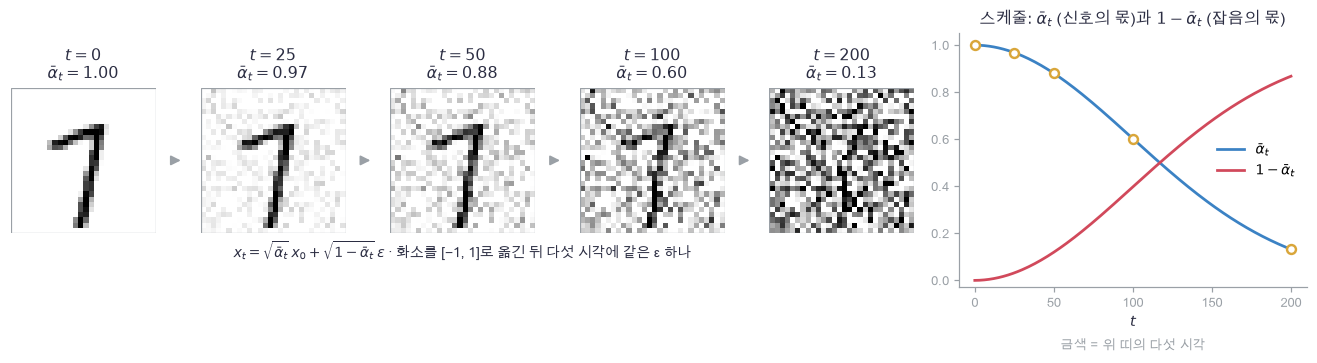

In [10]:
plot_forward_band(band_images, band_ts, alpha_bar)

🔍 **확인** · 왼쪽 띠에서 $t=25$까지는 7이 또렷하고($\bar\alpha_{25}=0.97$), $t=100$에서 겨우 보이며($0.60$), $t=200$에서는 잡음이 대부분입니다. 그래도 획의 자리가 희미하게 남아 있는데, $\sqrt{\bar\alpha_T}=0.36$이라 신호가 3분의 1쯤 살아 있기 때문입니다. 다섯 장 모두 **한 걸음씩 200번 돌린 것이 아니라** 닫힌식 한 줄로 만든 것입니다.
오른쪽 곡선에서 파랑 $\bar\alpha_t$(신호의 몫)와 빨강 $1-\bar\alpha_t$(잡음의 몫)는 항상 합이 1이고, 두 선이 만나는 곳이 신호와 잡음이 반반인 시각입니다. $\bar\alpha_T=0.13$이라 마지막에도 신호가 완전히 0은 아닙니다. 완성 예제에서 이 점을 고치는 코사인 스케줄과 비교합니다.

아래 구현은 스케줄 만들기와 닫힌식 한 줄, 그리고 1차원 혼합이 시각 $t$에서 갖는 밀도입니다. 셋 다 위에서 손으로 쓴 식을 그대로 옮긴 것입니다.

In [11]:
def make_schedule(T, beta_start=1e-4, beta_end=0.02):
    """선형 β 스케줄과 그 누적곱. β_t 는 t = 1…T 에서 beta_start → beta_end 로 선형, 번호 0 은 β₀ = 0.
    T: 걸음 수 → (beta: (T+1,), alpha: (T+1,), alpha_bar: (T+1,))."""
    assert T >= 1, "걸음 수는 1 이상이어야 합니다"
    assert 0 < beta_start <= beta_end < 1, "β 는 0 과 1 사이에서 커져야 합니다"
    beta = np.concatenate([[0.0], np.linspace(beta_start, beta_end, T)])
    alpha = 1 - beta
    return beta, alpha, np.cumprod(alpha)

In [12]:
def q_sample(x0, t, eps, alpha_bar):
    """닫힌식 전방 샘플 x_t = √ᾱ_t x₀ + √(1 − ᾱ_t) ε 한 줄. 표본마다 다른 t 를 줄 수 있습니다.
    x0: (N, D), t: (N,) 정수 또는 숫자 하나, eps: (N, D) → x_t: (N, D)."""
    ab = alpha_bar[np.asarray(t)].reshape(-1, 1)                     # (N, 1) 또는 (1, 1): 표본마다의 ᾱ_t
    return np.sqrt(ab) * x0 + np.sqrt(1 - ab) * eps

In [13]:
def q_t_logpdf(x, t, alpha_bar):
    """시각 t 에서 1차원 혼합의 log q(x_t): 성분 평균 √ᾱ_t μ_k, 분산 ᾱ_t σ_k² + (1 − ᾱ_t). x: (N,) → (N,)."""
    # 쓰는 것: MIX_PI, MIX_MU, MIX_SIGMA (📎 데이터 셀)
    ab = alpha_bar[t]
    means = np.sqrt(ab) * MIX_MU                                     # (2,): 성분 평균도 √ᾱ_t 배로 줄어듦
    variances = ab * MIX_SIGMA ** 2 + (1 - ab)                       # (2,): 줄어든 성분 분산 + 더한 잡음
    terms = np.log(MIX_PI) - 0.5 * (np.log(2 * np.pi * variances) + (x[:, None] - means) ** 2 / variances)
    biggest = terms.max(axis=1, keepdims=True)                       # (N, 1): 안정화
    return (biggest + np.log(np.exp(terms - biggest).sum(axis=1, keepdims=True)))[:, 0]

In [14]:
# 쓰는 것: T, beta, alpha, alpha_bar, band_x0, band_eps, band_ts (1절 계산 셀)
toy_beta, toy_alpha, toy_alpha_bar = make_schedule(2, 0.1, 0.2)      # 손계산용 두 걸음 스케줄
np.testing.assert_allclose(toy_beta, [0.0, 0.1, 0.2])                # 검산: 손계산 β = (0.1, 0.2)
np.testing.assert_allclose(toy_alpha_bar, [1.0, 0.9, 0.72])          # 검산: 손계산 ᾱ₂ = 0.9 × 0.8
np.testing.assert_allclose(1 - toy_alpha_bar[2], 0.8 * 0.1 + 0.2)    # 검산: 잡음 분산 α₂β₁ + β₂ = 1 − ᾱ₂ = 0.28
for name, made, inline in zip(["beta", "alpha", "alpha_bar"], make_schedule(T), [beta, alpha, alpha_bar]):
    np.testing.assert_allclose(made, inline)                         # 검산: 함수가 위 계산 셀과 같은 스케줄을 만듦
band_again = q_sample(band_x0.reshape(1, -1), band_ts[3], band_eps.reshape(1, -1), alpha_bar)   # (1, 784): t = 100 한 장
np.testing.assert_allclose(band_again.reshape(28, 28), np.sqrt(alpha_bar[100]) * band_x0 + np.sqrt(1 - alpha_bar[100]) * band_eps)   # 검산: 그림의 t = 100 과 같은 식
print("장난감 스케줄 ᾱ:", toy_alpha_bar, "· 잡음 분산 0.28 = 1 − 0.72 · make_schedule 이 계산 셀과 일치")

장난감 스케줄 ᾱ: [1.   0.9  0.72] · 잡음 분산 0.28 = 1 − 0.72 · make_schedule 이 계산 셀과 일치


🔍 **확인** · 손계산 $\bar\alpha_2=0.72$와 잡음 분산 $0.28$이 맞습니다. 그런데 이것만으로는 "닫힌식이 정말 200걸음을 대신하는가"를 확인하지 못했습니다. 아래에서 점 40,000개를 **실제로 한 걸음씩 200번** 굴려 평균과 분산을 재고, 닫힌식 $\sqrt{\bar\alpha_t}x_0$·$1-\bar\alpha_t$와 비교합니다.

In [15]:
# 쓰는 것: T, alpha, beta, alpha_bar (1절 계산 셀)
walk_rng = np.random.default_rng(3401)
walk_x = np.full(40000, 1.5)                                         # (40000,): 모두 같은 x₀ = 1.5 에서 출발
walk_stats = {}                                                      # t → (표본 평균, 표본 분산)
for t in range(1, T + 1):
    walk_x = np.sqrt(alpha[t]) * walk_x + np.sqrt(beta[t]) * walk_rng.normal(size=40000)   # 한 걸음 규칙 그대로
    if t in (50, 100, 200):
        walk_stats[t] = (float(walk_x.mean()), float(walk_x.var()))
for t, (mean_t, var_t) in walk_stats.items():
    mean_closed, var_closed = np.sqrt(alpha_bar[t]) * 1.5, 1 - alpha_bar[t]
    mean_gap, var_gap = abs(mean_t - mean_closed) / mean_closed, abs(var_t - var_closed) / var_closed
    assert mean_gap < 0.03, f"t = {t}: 한 걸음씩 굴린 평균이 닫힌식과 3% 안에서 같아야 합니다"
    assert var_gap < 0.03, f"t = {t}: 한 걸음씩 굴린 분산이 닫힌식과 3% 안에서 같아야 합니다"
    print(f"t = {t:3d}: 평균 {mean_t: .4f} vs 닫힌식 {mean_closed: .4f} (상대오차 {mean_gap:.4f}) · 분산 {var_t:.4f} vs {var_closed:.4f} ({var_gap:.4f})")

t =  50: 평균  1.4076 vs 닫힌식  1.4072 (상대오차 0.0003) · 분산 0.1192 vs 0.1199 (0.0055)
t = 100: 평균  1.1670 vs 닫힌식  1.1643 (상대오차 0.0023) · 분산 0.3993 vs 0.3975 (0.0044)
t = 200: 평균  0.5508 vs 닫힌식  0.5454 (상대오차 0.0100) · 분산 0.8741 vs 0.8678 (0.0072)


### 🔍 1-1. 혼합 분포 전체는 시각 $t$에서 어떤 모양인가

한 점이 아니라 분포 전체를 흘려보내면 어떻게 될까요? 성분이 Gaussian이면 답도 닫힌식입니다. $x_0\sim\mathcal N(\mu_k,\sigma_k^2)$에 $x_t=\sqrt{\bar\alpha_t}x_0+\sqrt{1-\bar\alpha_t}\epsilon$을 적용하면 평균은 $\sqrt{\bar\alpha_t}\mu_k$, 분산은 $\bar\alpha_t\sigma_k^2+(1-\bar\alpha_t)$입니다. 비율 $\pi_k$는 그대로이므로 $q(x_t)$도 성분 두 개짜리 혼합입니다. 위 `q_t_logpdf`가 그 식입니다.
아래에서 표본 10,000개를 `q_sample`로 만들어 히스토그램과 겹쳐 봅니다.

> **코드** · `np.histogram(v, edges)[0]`: 구간 경계 `edges`로 나눈 개수 `(len(edges) − 1,)`. 개수를 (표본 수 × 구간 폭)으로 나누면 밀도와 같은 눈금이 됩니다.

In [16]:
# 쓰는 것: alpha_bar (1절 계산 셀) · mix_sample (📎 혼합 셀) · q_sample, q_t_logpdf (1절)
hist_ts = [0, 50, 200]                                               # 밀도를 볼 세 시각
hist_x = np.linspace(-6, 6, 1201)                                    # (1201,): 밀도 격자
hist_edges = np.linspace(-6, 6, 61)                                  # (61,): 히스토그램 구간 경계 (폭 0.2)
hist_centers = 0.5 * (hist_edges[1:] + hist_edges[:-1])              # (60,)
hist_rng = np.random.default_rng(342)
hist_x0 = mix_sample(10000, hist_rng)[:, None]                       # (10000, 1): 원래 분포의 표본
hist_pdfs, hist_counts, hist_tvs = [], [], []
for t in hist_ts:
    samples = q_sample(hist_x0, t, hist_rng.normal(size=hist_x0.shape), alpha_bar)[:, 0]   # (10000,): 시각 t 의 표본
    density = np.exp(q_t_logpdf(hist_x, t, alpha_bar))               # (1201,): 닫힌식 q(x_t)
    counts = np.histogram(samples, hist_edges)[0] / (10000 * 0.2)    # (60,): 밀도 눈금의 히스토그램
    hist_pdfs.append(density)
    hist_counts.append(counts)
    hist_tvs.append(0.5 * np.sum(np.abs(counts - np.exp(q_t_logpdf(hist_centers, t, alpha_bar)))) * 0.2)   # TV 거리
assert max(hist_tvs) < 0.03, "세 시각 모두 표본 히스토그램과 닫힌식의 TV 거리가 0.03 아래여야 합니다"
print("TV 거리 (t =", hist_ts, "):", np.round(hist_tvs, 4))

TV 거리 (t = [0, 50, 200] ): [0.0244 0.0215 0.0161]


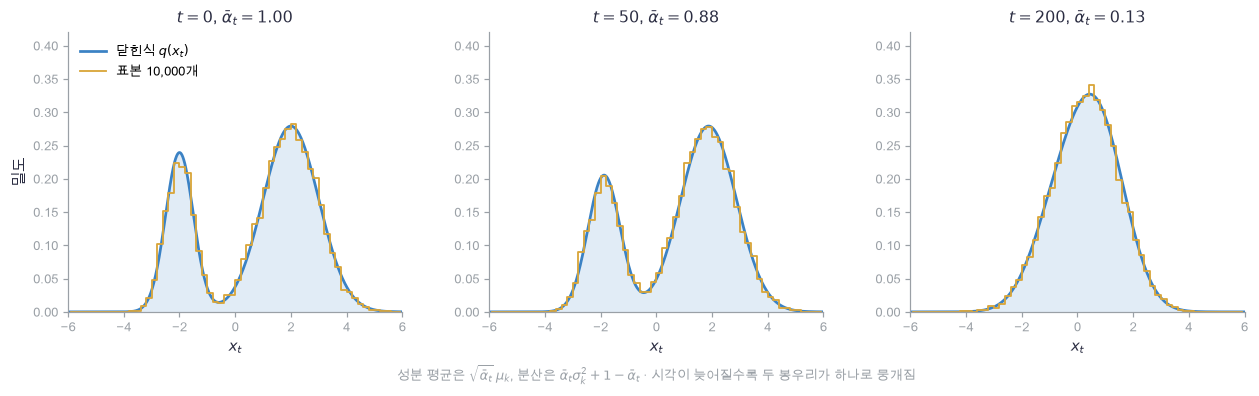

In [17]:
plot_mixture_forward(hist_x, hist_ts, alpha_bar[hist_ts], hist_pdfs, hist_centers, hist_counts)

🔍 **확인** · $t=0$은 원래 두 봉우리이고, $t=50$에서 봉우리가 서로 가까워지며 골이 얕아지고, $t=200$에서는 봉우리 하나로 합쳐집니다. 다만 $\bar\alpha_T=0.13$이라 평균 $0.29$·분산 $1.41$로 아직 $\mathcal N(0,1)$은 아닙니다(완성 예제의 코사인 스케줄에서 이 차이가 사라집니다). 봉우리가 가까워지는 것은 평균이 $\sqrt{\bar\alpha_t}\mu_k$로 **0 쪽으로 줄어들기** 때문이고, 골이 메워지는 것은 분산에 $1-\bar\alpha_t$가 더해지기 때문입니다.
금색 계단(표본)과 파란 곡선(닫힌식)이 세 시각 모두 TV 거리 $0.03$ 안에서 겹칩니다. 33번의 $\sigma$ 사다리와 다른 점은 신호도 함께 줄어든다는 것뿐입니다. 3절에서 둘을 정확히 이어 붙입니다.

### ✏️ 연습 1 · β 에서 ᾱ 까지

연습은 코딩 테스트처럼 **함수 뼈대가 미리 있고 핵심 한두 줄만 비어 있습니다.** `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓴 뒤, 셀을 실행하고 바로 아래 검사 셀을 실행하세요. 아직 채우지 않았으면 안내문만 나오고, 값이 다르면 "손계산과 다릅니다"가 나옵니다. 막히면 그 아래 "정답 보기"를 펼칩니다.

스케줄 `beta_values` `(T+1,)`(번호 0 은 $\beta_0=0$)에서 $\alpha_t=1-\beta_t$와 그 누적곱 $\bar\alpha_t$를 만드는 두 줄을 채우세요. 이 두 줄이 1절 전체의 출발점이고, 나머지는 모두 $\bar\alpha_t$만 씁니다.

In [18]:

def exercise_alpha_bar(beta_values):
    """연습 1: β 에서 α 와 누적곱 ᾱ 를 만듭니다. beta_values: (T+1,) → (alpha: (T+1,), alpha_bar: (T+1,))."""
    assert beta_values[0] == 0.0, "번호 0 은 아직 잡음을 더하지 않은 시각이라 β₀ = 0 이어야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: alpha = 1 − beta_values (모양 (T+1,)), alpha_bar = alpha 의 누적곱 (모양 (T+1,))
    ### 힌트: 1절 계산 셀의 두 줄입니다. 누적곱은 np.cumprod(alpha) 입니다.
    raise NotImplementedError
    return alpha, alpha_bar

In [19]:

def check_alpha_bar(candidate):
    """1절 손계산(장난감 스케줄)과 본문 스케줄, ᾱ 가 단조 감소하는지로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: beta, alpha, alpha_bar (1절 계산 셀)
    toy_alpha_c, toy_bar_c = candidate(np.array([0.0, 0.1, 0.2]))
    np.testing.assert_allclose(toy_alpha_c, [1.0, 0.9, 0.8])                  # 검산: 손계산 α = 1 − β
    np.testing.assert_allclose(toy_bar_c, [1.0, 0.9, 0.72])                   # 검산: 손계산 ᾱ₂ = 0.9 × 0.8
    alpha_c, bar_c = candidate(beta)
    np.testing.assert_allclose([alpha_c, bar_c], [alpha, alpha_bar])          # 검산: 본문 스케줄과 같음
    assert np.all(np.diff(bar_c) <= 0), "ᾱ_t 는 t 가 커질수록 줄어들어야 합니다"
    print("β → α → ᾱ: 손계산·본문 스케줄과 일치합니다.")

run_check(check_alpha_bar, exercise_alpha_bar, hint="alpha = 1 - beta_values · alpha_bar = np.cumprod(alpha)")

☐ exercise_alpha_bar: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: alpha = 1 - beta_values · alpha_bar = np.cumprod(alpha)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
alpha = 1 - beta_values
alpha_bar = np.cumprod(alpha)
```

</details>

## 🔑 2. 되묻기: $x_t$와 $x_0$를 함께 알면 $x_{t-1}$은 어디에 있었나

**이 절에서 가져갈 것:** $q(x_{t-1}\mid x_t,x_0)$도 Gaussian이고, 평균은 두 정보의 가중합 $\tilde\mu_t=c_0(t)\,x_0+c_t(t)\,x_t$, 분산은 $\tilde\beta_t=\frac{1-\bar\alpha_{t-1}}{1-\bar\alpha_t}\beta_t$입니다. $\tilde\beta_t\le\beta_t$이므로, $x_0$를 알고 되묻는 일은 앞으로 한 걸음 가는 일보다 언제나 덜 불확실합니다.

되돌아오려면 "한 걸음 뒤로"가 무엇인지 알아야 합니다. $x_t$만 보고 $x_{t-1}$을 되묻는 것은 어렵지만, **원본 $x_0$를 함께 아는 척**하면 정확한 답이 나옵니다. 학습할 때는 $x_0$를 실제로 알고 있으니 이 답을 정답지로 쓸 수 있고, 35번의 역과정은 여기에 $x_0$ 대신 예측값을 넣습니다.

> **용어**
>
> - **posterior(사후 분포)**: 관측을 보고 난 뒤의 분포. 여기서는 $x_t$와 $x_0$를 보고 난 뒤의 $x_{t-1}$ 분포입니다. 앞으로 가는 분포 $q(x_t\mid x_{t-1})$와 방향이 반대입니다.
> - **완성제곱(completing the square)**: 지수 안의 이차식 $ax^2-2bx$를 $a(x-b/a)^2+\text{상수}$로 다시 묶는 계산. Gaussian 둘의 곱이 다시 Gaussian임을 보이는 도구입니다. 12번 2절의 로그 밀도 식을 $x_{t-1}$에 대해 다시 묶는 계산이고, 이 노트북에서 처음 씁니다.

Bayes 규칙으로 두 Gaussian의 곱을 씁니다. $x_0$를 고정했으므로 $x_{t-1}$에 대한 항만 남습니다.

$$q(x_{t-1}\mid x_t,x_0)\;\propto\;\underbrace{\mathcal N(x_t;\sqrt{\alpha_t}\,x_{t-1},\,\beta_t)}_{\text{앞으로 한 걸음}}\;\underbrace{\mathcal N(x_{t-1};\sqrt{\bar\alpha_{t-1}}\,x_0,\,1-\bar\alpha_{t-1})}_{1\text{절의 닫힌식}}.$$

지수 안에서 $x_{t-1}$의 이차항 계수를 모으면

$$\frac{\alpha_t}{\beta_t}+\frac{1}{1-\bar\alpha_{t-1}}=\frac{\alpha_t(1-\bar\alpha_{t-1})+\beta_t}{\beta_t(1-\bar\alpha_{t-1})}=\frac{1-\bar\alpha_t}{\beta_t(1-\bar\alpha_{t-1})}=\frac{1}{\tilde\beta_t}$$

입니다($\alpha_t-\bar\alpha_t+1-\alpha_t=1-\bar\alpha_t$를 썼습니다). 일차항에 $\tilde\beta_t$를 곱하면 평균이 나옵니다.

$$\tilde\mu_t=\underbrace{\frac{\sqrt{\bar\alpha_{t-1}}\,\beta_t}{1-\bar\alpha_t}}_{c_0(t)}\,x_0+\underbrace{\frac{\sqrt{\alpha_t}\,(1-\bar\alpha_{t-1})}{1-\bar\alpha_t}}_{c_t(t)}\,x_t,\qquad
\tilde\beta_t=\frac{1-\bar\alpha_{t-1}}{1-\bar\alpha_t}\,\beta_t.$$

$x_0$와 $x_t$는 $(N,D)$, $c_0(t)$·$c_t(t)$·$\tilde\beta_t$는 시각마다 숫자 하나입니다. 좌표마다 같은 계수를 쓰므로 브로드캐스팅으로 곱하면 됩니다. $1-\bar\alpha_{t-1}\le1-\bar\alpha_t$이므로 $\tilde\beta_t\le\beta_t$입니다.

**손계산** 1절의 장난감 스케줄 $\beta=(0.1,0.2)$에서 $t=2$: $\bar\alpha_1=0.9$, $\bar\alpha_2=0.72$, $1-\bar\alpha_2=0.28$이므로
$c_0=\frac{\sqrt{0.9}\times0.2}{0.28}=\frac{0.18974}{0.28}=0.67763$, $c_t=\frac{\sqrt{0.8}\times0.1}{0.28}=\frac{0.089443}{0.28}=0.31944$, $\tilde\beta_2=\frac{0.1}{0.28}\times0.2=\frac{1}{14}=0.071429$입니다.

아래는 $t$ 축을 따라 본 두 계수와 $\tilde\beta_t$, 그리고 $t=50$·$x_0=1.5$·$x_t=0.9$에서 격자 위에서 Bayes 규칙을 **직접 적분해** 구한 posterior입니다.

> **코드**
>
> - `alpha_bar[post_ts - 1]`: 정수 배열로 여러 자리를 한 번에 고릅니다. $t$ 배열에 대해 $\bar\alpha_{t-1}$을 한 줄로 얻습니다.
> - `np.trapezoid(y, x)`: 사다리꼴 규칙의 수치 적분 $\int y\,dx$. 밀도를 정규화하고 평균·분산을 잴 때 씁니다.

In [20]:
# 쓰는 것: beta, alpha, alpha_bar, T (1절 계산 셀)
post_ts = np.arange(1, T + 1)                                        # (200,): t = 1…T
post_c0 = np.sqrt(alpha_bar[post_ts - 1]) * beta[post_ts] / (1 - alpha_bar[post_ts])          # (200,): x₀ 의 계수
post_ct = np.sqrt(alpha[post_ts]) * (1 - alpha_bar[post_ts - 1]) / (1 - alpha_bar[post_ts])   # (200,): x_t 의 계수
post_beta_tilde = (1 - alpha_bar[post_ts - 1]) / (1 - alpha_bar[post_ts]) * beta[post_ts]     # (200,): 되묻기의 분산
post_ratio = post_beta_tilde / beta[post_ts]                          # (200,): β̃_t/β_t. 1 보다 작으면 되묻기가 더 확실함
post_t, post_x0, post_xt = 50, 1.5, 0.9                              # 격자로 직접 적분해 볼 한 경우
post_grid = np.linspace(-2, 4, 120001)                               # (120001,): x_{t−1} 격자 (간격 5e−5)
post_like = np.exp(-0.5 * (post_xt - np.sqrt(alpha[post_t]) * post_grid) ** 2 / beta[post_t])          # 앞으로 한 걸음의 밀도
post_prior = np.exp(-0.5 * (post_grid - np.sqrt(alpha_bar[post_t - 1]) * post_x0) ** 2 / (1 - alpha_bar[post_t - 1]))   # 1절 닫힌식
post_pdf = post_like * post_prior
post_pdf = post_pdf / np.trapezoid(post_pdf, post_grid)              # 넓이가 1이 되게 (정규화 상수는 몰라도 됨)
post_grid_mean = float(np.trapezoid(post_grid * post_pdf, post_grid))
post_grid_var = float(np.trapezoid((post_grid - post_grid_mean) ** 2 * post_pdf, post_grid))
print(f"t = {post_t}: 격자 적분 평균 {post_grid_mean:.6f}, 분산 {post_grid_var:.6f} · 계수 c₀ {post_c0[post_t - 1]:.4f}, c_t {post_ct[post_t - 1]:.4f}")

t = 50: 격자 적분 평균 0.923464, 분산 0.004816 · 계수 c₀ 0.0392, c_t 0.9607


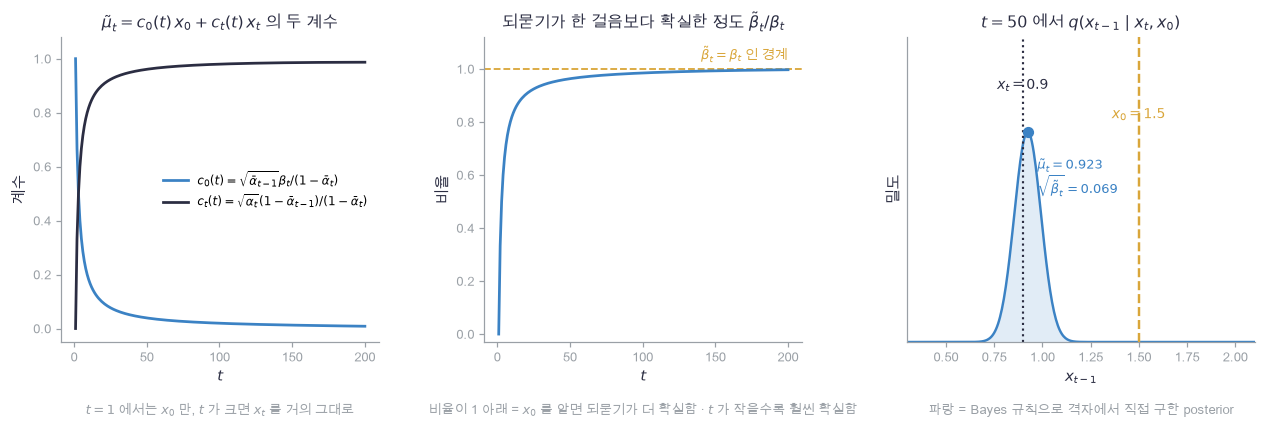

In [21]:
plot_posterior_coefficients(post_ts, post_c0, post_ct, post_ratio,
                            {"t": post_t, "x0": post_x0, "xt": post_xt, "grid": post_grid[::100], "pdf": post_pdf[::100],
                             "mean": post_grid_mean, "std": float(np.sqrt(post_grid_var))})

🔍 **확인** · 왼쪽에서 $t=1$일 때는 $c_0=1$, $c_t=0$입니다. 한 걸음 전은 곧 $x_0$이니 당연합니다. $t$가 커질수록 $c_0$는 0으로, $c_t$는 1로 갑니다. 먼 과거에서는 "$x_0$가 무엇인지"보다 "지금 어디 있는지"가 한 걸음 전을 거의 결정합니다.
가운데는 두 분산의 비율 $\tilde\beta_t/\beta_t$입니다. 값이 언제나 1 아래이므로 $\tilde\beta_t\le\beta_t$입니다. $t$가 작을수록 비율이 크게 떨어집니다. $t=1$에서는 되묻기가 곧 $x_0$이라 불확실성이 0입니다. $t$가 커지면 비율이 1에 가까워지는데, 먼 과거에서는 $x_0$를 알아도 한 걸음 전을 그만큼 더 잘 알지는 못한다는 뜻입니다.
오른쪽은 $t=50$에서 격자로 적분한 posterior이고, 금색 $x_0=1.5$보다 검은 $x_t=0.9$ 쪽에 훨씬 가깝습니다. $t=50$에서 이미 $c_t=0.961$이기 때문입니다.

아래 구현은 위 두 계수와 분산을 그대로 돌려주는 함수이고, 검산은 손계산·격자 적분·$\tilde\beta_t\le\beta_t$를 봅니다.

In [22]:
def posterior_coefficients(t, beta, alpha_bar):
    """q(x_{t−1} | x_t, x₀) = N(c₀ x₀ + c_t x_t, β̃_t) 의 계수. 완성제곱으로 얻은 위 세 식 그대로.
    t: 정수 또는 정수 배열, beta·alpha_bar: (T+1,) → (c0, c_t, beta_tilde) (t 와 같은 모양)."""
    t = np.asarray(t)
    assert np.all(t >= 1), "되묻기는 t = 1 부터 정의됩니다 (t − 1 이 있어야 합니다)"
    ab, ab_prev = alpha_bar[t], alpha_bar[t - 1]                      # ᾱ_t 와 ᾱ_{t−1}
    c0 = np.sqrt(ab_prev) * beta[t] / (1 - ab)                        # √ᾱ_{t−1} β_t / (1 − ᾱ_t)
    ct = np.sqrt(1 - beta[t]) * (1 - ab_prev) / (1 - ab)              # √α_t (1 − ᾱ_{t−1}) / (1 − ᾱ_t)
    return c0, ct, (1 - ab_prev) / (1 - ab) * beta[t]

In [23]:
# 쓰는 것: beta, alpha_bar (1절 계산 셀) · toy_beta, toy_alpha_bar (1절 검산 셀) · post_ts, post_c0, post_ct, post_beta_tilde, post_ratio, post_t, post_x0, post_xt, post_grid_mean, post_grid_var (2절 계산 셀)
toy_c0, toy_ct, toy_bt = posterior_coefficients(2, toy_beta, toy_alpha_bar)
np.testing.assert_allclose([toy_c0, toy_ct, toy_bt], [0.677631, 0.319438, 1 / 14], atol=1e-6)   # 검산: 손계산 0.18974/0.28, 0.089443/0.28, 0.1/0.28×0.2
grid_c0, grid_ct, grid_bt = posterior_coefficients(post_t, beta, alpha_bar)
closed_mean = grid_c0 * post_x0 + grid_ct * post_xt                  # 닫힌식 평균 c₀x₀ + c_t x_t
assert abs(closed_mean - post_grid_mean) / abs(post_grid_mean) < 1e-10, "닫힌식 평균이 격자 적분과 1e−10 안에서 같아야 합니다"
assert abs(grid_bt - post_grid_var) / post_grid_var < 1e-10, "닫힌식 분산이 격자 적분과 1e−10 안에서 같아야 합니다"
all_c0, all_ct, all_bt = posterior_coefficients(post_ts, beta, alpha_bar)
np.testing.assert_allclose([all_c0, all_ct, all_bt], [post_c0, post_ct, post_beta_tilde])   # 검산: 위 그림의 곡선과 같음
np.testing.assert_allclose(all_bt / beta[1:], post_ratio)                   # 검산: 위 그림 가운데 패널의 비율
np.testing.assert_allclose(posterior_coefficients(1, beta, alpha_bar), [1.0, 0.0, 0.0], atol=1e-12)   # 검산: t = 1 이면 되묻기가 곧 x₀
assert np.all(all_bt <= beta[1:] + 1e-15), "β̃_t 는 모든 t 에서 β_t 이하여야 합니다"
print(f"격자 적분 평균 {post_grid_mean:.8f} = 닫힌식 {closed_mean:.8f} · 분산 {post_grid_var:.8f} = β̃ {grid_bt:.8f}")

격자 적분 평균 0.92346355 = 닫힌식 0.92346355 · 분산 0.00481556 = β̃ 0.00481556


🔍 **확인** · 손계산 세 값 $(0.6776,\ 0.3194,\ 1/14)$이 맞고, $t=50$에서 격자로 직접 적분한 평균·분산이 닫힌식과 상대오차 $10^{-10}$ 안에서 같습니다. 완성제곱을 눈으로 따라가지 않아도, 두 계산이 소수점 여덟 자리까지 맞는 것으로 유도가 맞았음을 알 수 있습니다.
$t=1$에서 계수가 정확히 $(1,0)$이고 분산이 0인 것도 확인했습니다. 35번의 역과정 한 걸음은 이 $\tilde\mu_t$의 $x_0$ 자리에 **예측한 $\hat x_0$**를 넣은 것입니다.

### ✏️ 연습 2 · 되묻기의 분산 한 줄

시각 `t`와 스케줄에서 $\tilde\beta_t=\frac{1-\bar\alpha_{t-1}}{1-\bar\alpha_t}\beta_t$ 한 줄을 채우세요. 평균의 두 계수는 노트북 끝의 연습 B에서 다루므로, 여기서는 "되묻기가 한 걸음 잡음보다 얼마나 확실한가"를 재는 분산만 봅니다.

In [24]:

def exercise_beta_tilde(t, beta_values, alpha_bar_values):
    """연습 2: 되묻기의 분산 β̃_t. t: 정수 또는 정수 배열 → t 와 같은 모양."""
    assert np.all(np.asarray(t) >= 1), "되묻기는 t = 1 부터 정의됩니다"
    ab, ab_prev = alpha_bar_values[t], alpha_bar_values[np.asarray(t) - 1]   # ᾱ_t 와 ᾱ_{t−1}
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: beta_tilde = (1 − ab_prev)/(1 − ab) × β_t
    ### 힌트: 2절 posterior_coefficients 의 마지막 줄입니다. β_t 는 beta_values[t] 입니다.
    raise NotImplementedError
    return beta_tilde

In [25]:

def check_beta_tilde(candidate):
    """2절 손계산(1/14), 그림의 곡선, β̃_t ≤ β_t 로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: toy_beta, toy_alpha_bar (1절 검산 셀) · beta, alpha_bar (1절 계산 셀) · post_ts, post_beta_tilde (2절 계산 셀)
    np.testing.assert_allclose(candidate(2, toy_beta, toy_alpha_bar), 1 / 14, atol=1e-12)   # 검산: 손계산 0.1/0.28 × 0.2
    np.testing.assert_allclose(candidate(1, toy_beta, toy_alpha_bar), 0.0, atol=1e-12)      # 검산: t = 1 이면 x₀ 를 알므로 불확실성 0
    np.testing.assert_allclose(candidate(post_ts, beta, alpha_bar), post_beta_tilde)        # 검산: 2절 그림의 β̃_t 곡선
    assert np.all(candidate(post_ts, beta, alpha_bar) <= beta[1:] + 1e-15), "β̃_t 는 β_t 이하여야 합니다"
    print("되묻기의 분산: 손계산 1/14·그림의 곡선과 일치합니다.")

run_check(check_beta_tilde, exercise_beta_tilde, hint="beta_tilde = (1 - ab_prev) / (1 - ab) * beta_values[t]")

☐ exercise_beta_tilde: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: beta_tilde = (1 - ab_prev) / (1 - ab) * beta_values[t]


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
beta_tilde = (1 - ab_prev) / (1 - ab) * beta_values[t]
```

</details>

## 🔑 3. 무엇을 맞힐 것인가: $x_0$, $\epsilon$, 그리고 score는 같은 것의 세 얼굴

**이 절에서 가져갈 것:** $x_t=\sqrt{\bar\alpha_t}x_0+\sqrt{1-\bar\alpha_t}\epsilon$ 한 줄 때문에 "$x_0$ 맞히기"와 "$\epsilon$ 맞히기"는 서로 한 줄로 바뀌는 같은 문제입니다. 게다가 최적 $\epsilon$ 예측 $\epsilon^*(x_t)=\mathbb E[\epsilon\mid x_t]$는 32번의 score와 $\nabla_{x_t}\log q(x_t)=-\epsilon^*(x_t)/\sqrt{1-\bar\alpha_t}$로 이어집니다. 그래서 학습 목표는 $\mathbb E\|\epsilon-\epsilon_\theta(x_t,t)\|^2$ 하나면 됩니다.

$x_t$ 한 점을 신경망에 보여 주고 무엇을 내놓으라고 할까요? 후보가 셋입니다. 원본 $x_0$, 더한 잡음 $\epsilon$, 그리고 32번에서 배운 score. 셋 중 하나만 정하면 나머지 둘은 계산으로 따라옵니다.

> **용어**
>
> - **타깃(target)**: 회귀에서 맞혀야 할 정답값. 여기서는 배치를 만들 때 우리가 직접 뽑은 $\epsilon$을 그대로 정답으로 씁니다.
> - **$\epsilon$ 예측**: 모델이 $x_0$ 대신 $\epsilon$을 내게 하는 방식. DDPM 논문이 고른 방식이고, 5절에서 보듯 $t$마다의 손실 크기가 훨씬 고릅니다.
> - **단순화 손실(simple loss)** $L_{\text{simple}}=\mathbb E_{t,x_0,\epsilon}\|\epsilon-\epsilon_\theta(x_t,t)\|^2$: 시각 $t$를 고르게 뽑고, $\epsilon$을 뽑아 $x_t$를 만들고, 그 $\epsilon$을 맞히는 평범한 MSE 회귀.

**(1) 두 예측은 같은 것입니다.** 위 한 줄을 $x_0$에 대해 풀면 됩니다.

$$\hat x_0=\frac{x_t-\sqrt{1-\bar\alpha_t}\,\hat\epsilon}{\sqrt{\bar\alpha_t}},\qquad
\hat\epsilon=\frac{x_t-\sqrt{\bar\alpha_t}\,\hat x_0}{\sqrt{1-\bar\alpha_t}}.$$

$x_t$·$\hat x_0$·$\hat\epsilon$ 모두 $(N,D)$이고 계수는 숫자입니다. 제곱오차의 최소해는 조건부 평균이므로(32번 3절), 최적 예측은 $\hat x_0^*=\mathbb E[x_0\mid x_t]$와 $\epsilon^*=\mathbb E[\epsilon\mid x_t]$입니다. 기댓값은 선형이라 **두 최적 예측도 같은 한 줄로 이어집니다.**

**(2) score와도 같습니다.** $q(x_t)=\int q(x_0)\,\mathcal N(x_t;\sqrt{\bar\alpha_t}x_0,(1-\bar\alpha_t)I)\,dx_0$의 로그를 $x_t$로 미분하면, 적분 안의 Gaussian만 미분되어 조건부 평균이 남습니다.

$$\nabla_{x_t}\log q(x_t)=\mathbb E\!\left[-\frac{x_t-\sqrt{\bar\alpha_t}x_0}{1-\bar\alpha_t}\;\Big|\;x_t\right]=-\frac{\epsilon^*(x_t)}{\sqrt{1-\bar\alpha_t}}.$$

32번의 Tweedie 항등과 같은 식입니다. 신호가 $\sqrt{\bar\alpha_t}$배로 줄어든 것만 다릅니다.

**(3) 혼합에서는 정답을 닫힌식으로 씁니다.** 양변을 $\sqrt{\bar\alpha_t}$로 나누면 33번까지 쓰던 "신호는 그대로, 잡음만 더하는" 모양이 됩니다.

$$\frac{x_t}{\sqrt{\bar\alpha_t}}=x_0+\sigma_t\,\epsilon,\qquad \sigma_t=\sqrt{\frac{1-\bar\alpha_t}{\bar\alpha_t}}
\quad\Longrightarrow\quad \mathbb E[x_0\mid x_t]=\texttt{mix\_denoiser}\!\left(\frac{x_t}{\sqrt{\bar\alpha_t}},\ \sigma_t\right).$$

즉 23번 5절의 최적 복원을 좌표만 바꿔 그대로 쓸 수 있고, 거기서 $\epsilon^*$가 따라 나옵니다.

**손계산** $\bar\alpha_t=0.64$, $x_0=1$, $\epsilon=0.5$: $x_t=\sqrt{0.64}\cdot1+\sqrt{0.36}\cdot0.5=0.8+0.3=1.1$. 되돌리면 $\hat\epsilon=(1.1-0.8)/0.6=0.5$, $\hat x_0=(1.1-0.3)/0.8=1$로 제자리입니다. 그리고 $\sigma_t=\sqrt{0.36/0.64}=0.75$입니다.

아래는 세 시각에서 $q(x_t)$ 위에 그린 최적 $x_0$ 예측과 최적 $\epsilon$ 예측입니다. 두 곡선은 위 한 줄로 서로 옮겨집니다.

In [26]:
# 쓰는 것: alpha_bar (1절 계산 셀) · mix_denoiser (📎 혼합 셀) · q_t_logpdf (1절)
target_ts = [20, 80, 160]                                            # 최적 예측을 볼 세 시각
target_x = np.linspace(-4, 4, 801)                                   # (801,): x_t 격자
target_pdfs, target_x0_hats, target_eps_stars, target_sigmas = [], [], [], []
target_naives = []                                                   # 잡음을 무시하고 신호만 되돌린 선 x_t/√ᾱ_t
for t in target_ts:
    ab = alpha_bar[t]
    sigma_t = np.sqrt((1 - ab) / ab)                                 # σ_t: 신호를 1 로 맞췄을 때의 잡음 크기
    x0_hat = mix_denoiser(target_x / np.sqrt(ab), sigma_t)           # (801,): E[x₀ | x_t] (23번 5절을 좌표만 바꿔서)
    target_pdfs.append(np.exp(q_t_logpdf(target_x, t, alpha_bar)))   # (801,): q(x_t)
    target_x0_hats.append(x0_hat)
    target_eps_stars.append((target_x - np.sqrt(ab) * x0_hat) / np.sqrt(1 - ab))   # (801,): ε* = (x_t − √ᾱ x̂₀)/√(1−ᾱ)
    target_naives.append(target_x / np.sqrt(ab))                     # (801,): x_t/√ᾱ_t (잡음이 없다고 치면 이 선)
    target_sigmas.append(sigma_t)
print("ᾱ_t:", alpha_bar[target_ts].round(4), "· σ_t = √((1−ᾱ)/ᾱ):", np.round(target_sigmas, 4))
print("손계산 ᾱ = 0.64, x₀ = 1, ε = 0.5 → x_t =", 0.8 + 0.3, "· σ_t =", round(float(np.sqrt(0.36 / 0.64)), 4))

ᾱ_t: [0.9792 0.7226 0.2739] · σ_t = √((1−ᾱ)/ᾱ): [0.1457 0.6196 1.6281]
손계산 ᾱ = 0.64, x₀ = 1, ε = 0.5 → x_t = 1.1 · σ_t = 0.75


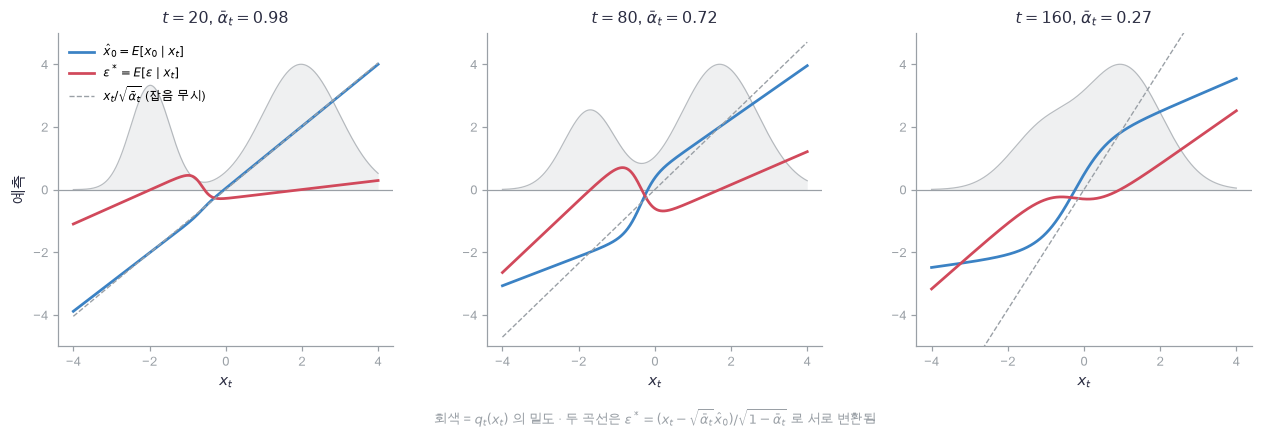

In [27]:
plot_targets(target_x, target_ts, alpha_bar[target_ts], target_pdfs, target_x0_hats, target_eps_stars,
             target_naives)

🔍 **확인** · $t=20$에서 파란 $\hat x_0$ 곡선은 거의 대각선입니다. 잡음이 작아 $x_t$가 곧 $x_0$이기 때문입니다. $t=160$에서는 곡선이 완만해지고 $-2$ 근처에 평평한 구간이 생깁니다. 잡음이 크면 "어느 봉우리에서 왔는지"가 주로 결정되고 그 안에서의 위치는 흐릿해집니다.
빨간 $\epsilon^*$ 곡선은 반대입니다. $t=20$에서는 데이터가 있는 자리(회색 봉우리 아래)에서 거의 0에 납작합니다. 잡음이 작으면 $x_t$를 보아도 그 잡음이 무엇이었는지 알 수 없어, 최선의 예측이 "거의 모르겠다"인 0 근처가 됩니다. $t=160$에서는 $x_t$가 대부분 잡음이라 $\epsilon^*\approx x_t/\sqrt{1-\bar\alpha_t}$로 기울기가 뚜렷합니다. 회색 점선 $x_t/\sqrt{\bar\alpha_t}$는 "잡음을 무시하고 신호만 되돌린" 값이고, 파란 곡선이 거기서 데이터 쪽으로 당겨진 만큼이 최적 복원이 하는 일입니다.
두 곡선은 서로 독립이 아닙니다. 아래 구현과 검산에서 한 줄 변환·중심차분·조건부 평균의 Monte Carlo 추정으로 확인합니다.

In [28]:
def optimal_eps(x_t, t, alpha_bar):
    """1차원 혼합에서 최적 잡음 예측 ε*(x_t) = (x_t − √ᾱ_t E[x₀|x_t])/√(1−ᾱ_t), E[x₀|x_t] = mix_denoiser(x_t/√ᾱ_t, σ_t).
    x_t: (N,), t: 정수 → (N,)."""
    # 쓰는 것: mix_denoiser (📎 혼합 셀)
    ab = alpha_bar[t]
    x0_hat = mix_denoiser(x_t / np.sqrt(ab), np.sqrt((1 - ab) / ab))  # (N,): 23번 5절을 σ_t 로
    return (x_t - np.sqrt(ab) * x0_hat) / np.sqrt(1 - ab)


def optimal_eps2(X_t, t, alpha_bar):
    """2차원 판. E[x₀|x_t] = mix2_denoiser(X_t/√ᾱ_t, σ_t). X_t: (N, 2), t: 정수 → (N, 2)."""
    # 쓰는 것: mix2_denoiser (📎 혼합 셀)
    ab = alpha_bar[t]
    X0_hat = mix2_denoiser(X_t / np.sqrt(ab), np.sqrt((1 - ab) / ab))
    return (X_t - np.sqrt(ab) * X0_hat) / np.sqrt(1 - ab)

In [29]:
def q_t_score(x, t, alpha_bar):
    """시각 t 혼합의 score ∇ log q(x_t) = Σ_k r_k (m_k − x)/v_k, m_k = √ᾱ_t μ_k, v_k = ᾱ_t σ_k² + 1 − ᾱ_t. x: (N,) → (N,)."""
    # 쓰는 것: MIX_PI, MIX_MU, MIX_SIGMA (📎 데이터 셀)
    ab = alpha_bar[t]
    means, variances = np.sqrt(ab) * MIX_MU, ab * MIX_SIGMA ** 2 + (1 - ab)
    terms = np.log(MIX_PI) - 0.5 * (np.log(2 * np.pi * variances) + (x[:, None] - means) ** 2 / variances)
    r = np.exp(terms - terms.max(axis=1, keepdims=True))              # (N, 2): 책임확률 (정규화 전)
    r = r / r.sum(axis=1, keepdims=True)
    return np.sum(r * (means - x[:, None]) / variances, axis=1)


def mix_score_noisy(x, sigma):
    """32번 3절: 잡음만 더한 혼합 q_σ 의 score Σ_k r_k^σ(x) (μ_k − x)/(σ_k² + σ²). x: (N,) → (N,)."""
    # 쓰는 것: MIX_MU, MIX_SIGMA (📎 데이터 셀) · mix_responsibility (📎 혼합 셀)
    r = mix_responsibility(x, sigma)
    return np.sum(r * (MIX_MU - x[:, None]) / (MIX_SIGMA ** 2 + sigma ** 2), axis=1)

In [30]:
# 쓰는 것: alpha_bar (1절 계산 셀) · target_x, target_ts, target_eps_stars (3절 계산 셀) · q_t_logpdf (1절)
hand_ab, hand_x0, hand_eps = 0.64, 1.0, 0.5
hand_xt = np.sqrt(hand_ab) * hand_x0 + np.sqrt(1 - hand_ab) * hand_eps
np.testing.assert_allclose(hand_xt, 1.1)                                                     # 검산: 손계산 0.8 + 0.3
np.testing.assert_allclose((hand_xt - np.sqrt(hand_ab) * hand_x0) / np.sqrt(1 - hand_ab), hand_eps)   # 검산: ε 로 되돌리면 0.5
np.testing.assert_allclose((hand_xt - np.sqrt(1 - hand_ab) * hand_eps) / np.sqrt(hand_ab), hand_x0)   # 검산: x₀ 로 되돌리면 1
for t, eps_star in zip(target_ts, target_eps_stars):
    np.testing.assert_allclose(optimal_eps(target_x, t, alpha_bar), eps_star)                 # 검산: 위 그림의 ε* 곡선
print("x₀ ↔ ε 왕복 변환과 그림의 ε* 곡선 일치 · x_t(손계산) =", hand_xt)

x₀ ↔ ε 왕복 변환과 그림의 ε* 곡선 일치 · x_t(손계산) = 1.1


In [31]:
# 쓰는 것: alpha_bar (1절 계산 셀) · q_t_logpdf (1절) · optimal_eps, q_t_score, mix_score_noisy (3절)
score_probe = np.random.default_rng(343).uniform(-4, 4, size=7)       # (7,): 검사 점
score_gaps = []
for t in [20, 80, 160]:
    ab = alpha_bar[t]
    from_eps = -optimal_eps(score_probe, t, alpha_bar) / np.sqrt(1 - ab)       # −ε*/√(1−ᾱ_t)
    from_mixture = q_t_score(score_probe, t, alpha_bar)                        # 시각 t 혼합의 닫힌식 score
    from_32 = mix_score_noisy(score_probe / np.sqrt(ab), np.sqrt((1 - ab) / ab)) / np.sqrt(ab)   # 32번의 q_σ score 를 좌표 변환

    def logq_sum():
        """검사기용: 검사 점들의 log q(x_t) 합. 점마다 독립이라 x_i 로 미분하면 score(x_i)."""
        return float(np.sum(q_t_logpdf(score_probe, t, alpha_bar)))

    numeric = numerical_gradient(logq_sum, score_probe)                        # 중심차분으로 잰 ∇ log q(x_t)
    score_gaps.append([rel_error(from_eps, from_mixture), rel_error(from_eps, from_32), rel_error(from_eps, numeric)])
score_gaps = np.array(score_gaps)
assert score_gaps[:, :2].max() < 1e-12, "닫힌식 세 가지가 1e−12 안에서 같아야 합니다"
assert score_gaps[:, 2].max() < 1e-7, "score 가 중심차분과 1e−7 안에서 같아야 합니다"
print(f"세 시각의 최대 상대오차 · 혼합 닫힌식 {score_gaps[:, 0].max():.2e} · 32번 변환 {score_gaps[:, 1].max():.2e} · 중심차분 {score_gaps[:, 2].max():.2e}")

세 시각의 최대 상대오차 · 혼합 닫힌식 6.33e-15 · 32번 변환 6.33e-15 · 중심차분 4.74e-10


In [32]:
# 쓰는 것: alpha_bar (1절 계산 셀) · mix_sample (📎 혼합 셀) · q_sample, optimal_eps (1·3절)
mc_t, mc_n = 80, 200000
mc_rng = np.random.default_rng(80)
mc_x0 = mix_sample(mc_n, mc_rng)[:, None]                             # (200000, 1): 원래 분포의 표본
mc_eps = mc_rng.normal(size=mc_x0.shape)                              # (200000, 1): 더한 잡음
mc_xt = q_sample(mc_x0, mc_t, mc_eps, alpha_bar)[:, 0]                # (200000,): 시각 t 의 표본
mc_edges = np.linspace(-4, 4, 33)                                     # (33,): x_t 구간 경계 (폭 0.25)
mc_bin = np.clip(np.digitize(mc_xt, mc_edges) - 1, 0, 31)             # (200000,): 각 표본의 구간 번호
mc_counts = np.bincount(mc_bin, minlength=32)                         # (32,): 구간별 표본 수
mc_sample_mean, mc_closed_mean = [], []                               # 구간별 ε 평균과 닫힌식 ε* 평균
for b in range(32):
    inside = mc_bin == b                                              # (200000,) bool: 이 구간에 든 표본
    if mc_counts[b] == 0:
        mc_sample_mean.append(np.nan)
        mc_closed_mean.append(np.nan)
        continue
    mc_sample_mean.append(float(mc_eps[inside, 0].mean()))            # 실제로 더한 ε 의 평균
    mc_closed_mean.append(float(optimal_eps(mc_xt[inside], mc_t, alpha_bar).mean()))   # 같은 표본에서 닫힌식 ε*
mc_gap = np.abs(np.array(mc_sample_mean) - np.array(mc_closed_mean))  # (32,): 두 평균의 차이
mc_dense = mc_counts >= 500                                           # 표본이 충분한 구간만 비교
assert np.nanmax(mc_gap[mc_dense]) < 0.06, "표본 500개 이상인 구간에서 ε 평균이 닫힌식 ε* 평균과 0.06 안에서 같아야 합니다"
print(f"t = {mc_t}: 표본 500개 이상 구간 {int(mc_dense.sum())}개 · 구간별 ε 평균과 닫힌식 ε* 의 최대 차이 {np.nanmax(mc_gap[mc_dense]):.4f}")

t = 80: 표본 500개 이상 구간 29개 · 구간별 ε 평균과 닫힌식 ε* 의 최대 차이 0.0384


🔍 **확인** · 세 가지 검산이 모두 통과했습니다. (1) $x_0\leftrightarrow\epsilon$ 왕복 변환이 손계산과 맞습니다. (2) $-\epsilon^*/\sqrt{1-\bar\alpha_t}$는 시각 $t$ 혼합의 닫힌식 score, 32번의 $q_\sigma$ score를 좌표 변환한 값과 $10^{-12}$ 안에서 같고, $\log q(x_t)$의 중심차분과도 $10^{-7}$ 안에서 같습니다. 서로 다른 세 경로로 계산한 값이 같으니 유도가 맞습니다.
(3) 마지막은 동어반복이 아닌 확인입니다. 표본 200,000개를 실제로 만들어 $x_t$ 구간마다 **실제로 더한 $\epsilon$의 평균**을 내고, 같은 표본에서 닫힌식 $\epsilon^*$의 평균과 비교하면 $0.06$ 안에서 같습니다. 한쪽은 잡음 그 자체의 평균이고 다른 쪽은 책임확률로 계산한 값인데 같습니다. 즉 $\epsilon^*$는 정말 조건부 평균 $\mathbb E[\epsilon\mid x_t]$이고, 신경망이 MSE로 배우는 것이 바로 이 값입니다.

### ✏️ 연습 3 · ε 예측을 x₀ 예측으로 바꾸기

모델이 낸 $\hat\epsilon$ `(N, D)`와 시각 `t`에서 $\hat x_0=\dfrac{x_t-\sqrt{1-\bar\alpha_t}\,\hat\epsilon}{\sqrt{\bar\alpha_t}}$ 한 줄을 채우세요. 노트북 끝의 연습 C가 "정답 $\epsilon^*$가 무엇인가"를 묻는다면, 이 연습은 "$\epsilon$을 받아 $x_0$로 돌아가는 한 줄"을 묻습니다. 4절과 5절이 계속 쓰는 줄입니다.

In [33]:

def exercise_eps_to_x0(x_t, eps_hat, t, alpha_bar_values):
    """연습 3: ε 예측을 x₀ 예측으로. x_t, eps_hat: (N, D), t: 정수 → x0_hat: (N, D)."""
    assert x_t.shape == eps_hat.shape, "x_t 와 ε̂ 는 같은 (N, D) 모양이어야 합니다"
    ab = alpha_bar_values[t]                                         # ᾱ_t (숫자 하나)
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: x0_hat = (x_t − √(1 − ab) × eps_hat) / √ab (모양 (N, D))
    ### 힌트: 3절의 변환 한 줄입니다. 반대 방향은 (x_t − √ab × x̂₀)/√(1 − ab) 였습니다.
    raise NotImplementedError
    return x0_hat

In [34]:

def check_eps_to_x0(candidate):
    """3절 손계산(ᾱ = 0.64, x_t = 1.1, ε̂ = 0.5 → 1), q_sample 과의 왕복, 5절 손실 환산으로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: alpha_bar (1절 계산 셀) · q_sample (1절)
    hand_bar = np.array([1.0, 0.64])                                 # 장난감 스케줄: ᾱ₁ = 0.64
    np.testing.assert_allclose(candidate(np.array([[1.1]]), np.array([[0.5]]), 1, hand_bar), [[1.0]])   # 검산: 손계산 (1.1 − 0.3)/0.8
    x0_c = np.random.default_rng(631).normal(size=(6, 2))
    eps_c = np.random.default_rng(632).normal(size=(6, 2))
    for t in [10, 90, 200]:
        x_t = q_sample(x0_c, t, eps_c, alpha_bar)                    # 같은 ε 으로 앞으로 갔다가
        np.testing.assert_allclose(candidate(x_t, eps_c, t, alpha_bar), x0_c)   # 검산: 그 ε 을 주면 정확히 x₀ 로 돌아옴
    wrong = candidate(q_sample(x0_c, 90, eps_c, alpha_bar), eps_c + 1.0, 90, alpha_bar)   # ε 을 1 만큼 틀리게 주면
    np.testing.assert_allclose(wrong - x0_c, -np.sqrt((1 - alpha_bar[90]) / alpha_bar[90]))   # 검산: 5절의 환산 √((1−ᾱ)/ᾱ) 만큼 벌어짐
    print("ε → x₀ 변환: 손계산·q_sample 왕복·5절 환산과 일치합니다.")

run_check(check_eps_to_x0, exercise_eps_to_x0, hint="x0_hat = (x_t - np.sqrt(1 - ab) * eps_hat) / np.sqrt(ab)")

☐ exercise_eps_to_x0: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: x0_hat = (x_t - np.sqrt(1 - ab) * eps_hat) / np.sqrt(ab)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
x0_hat = (x_t - np.sqrt(1 - ab) * eps_hat) / np.sqrt(ab)
```

</details>

## 🔑 4. 잡음 예측 신경망: 입력은 $(x_t,\,t)$, 출력은 $\hat\epsilon$

**이 절에서 가져갈 것:** 입력에 $x_t$와 **시각 $t$를 함께** 넣고 $\hat\epsilon$을 내는 MLP를 $\frac1N\sum_n\|\hat\epsilon_n-\epsilon_n\|^2$로 학습하면, 출력 기울기 $\frac2N(\hat\epsilon-\epsilon)$부터 뒤로는 03번 5절의 backward 그대로입니다. 시각은 배치마다 $\{1,\dots,T\}$에서 고르게 뽑아 모든 $t$를 한 모델이 함께 배웁니다.

3절에서 정답이 정해졌습니다. 이제 데이터를 만들기만 하면 01번의 회귀와 똑같습니다. 스텝마다 $x_0$를 뽑고, $t$를 뽑고, $\epsilon$을 뽑아 $x_t$를 만들고, 그 $\epsilon$을 맞히게 합니다.
한 가지만 새롭습니다. **같은 $x_t$라도 $t$가 다르면 정답이 다릅니다.** 3절 그림의 세 곡선이 서로 다른 것이 그 말입니다. 그래서 모델은 $t$가 몇인지도 알아야 합니다.

> **용어**
>
> - **시간 embedding(time embedding)** $\mathrm{emb}(t)$: 정수 시각 $t$를 여러 진동수의 sin·cos 값으로 펼친 길이 $E$의 벡터. 09번 4절의 sinusoidal 위치 표를 위치 대신 시각에 씁니다. $t$를 숫자 하나로 넣는 것보다 가까운 $t$끼리 비슷하고 먼 $t$끼리 구별되기 쉽습니다.
> - **조건 입력(conditioning)**: 예측을 바꾸는 추가 정보를 입력에 이어 붙이는 것. 여기서는 $t$가 그 정보입니다.

$$\mathrm{emb}(t)_{2i}=\sin\!\left(\frac{t}{10000^{2i/E}}\right),\qquad \mathrm{emb}(t)_{2i+1}=\cos\!\left(\frac{t}{10000^{2i/E}}\right).$$

$t$가 $(N,)$이면 $\mathrm{emb}(t)$는 $(N,E)$입니다. 이것을 $x_t$ 옆에 붙여 모델에 넣습니다. 데이터 차원을 $D$, 은닉 폭을 $H$라 하면

$$U=[\,x_t\;\;\mathrm{emb}(t)\,]\in\mathbb R^{N\times(D+E)},\qquad
Z=UW_1+b_1,\quad A=\tanh Z,\quad \hat\epsilon=AW_2+b_2\in\mathbb R^{N\times D}$$

이고 $W_1$은 $(D+E,H)$, $W_2$는 $(H,D)$입니다. 손실과 출력 기울기는

$$J=\frac1N\sum_{n=1}^{N}\|\hat\epsilon_n-\epsilon_n\|^2,\qquad \frac{\partial J}{\partial\hat\epsilon}=\frac2N(\hat\epsilon-\epsilon)\in\mathbb R^{N\times D}$$

입니다. 관측 축은 평균, 좌표 축은 합입니다. 그 아래로는 03번 5절의 두 층 backward가 그대로입니다: $dW_2=A^\top d\hat\epsilon$, $db_2=\sum d\hat\epsilon$, $dA=d\hat\epsilon\,W_2^\top$, $dZ=dA\odot(1-A^2)$, $dW_1=U^\top dZ$, $db_1=\sum dZ$.

**손계산** $N=2$, $D=2$: $\hat\epsilon=\begin{pmatrix}0.5&-1\\0&2\end{pmatrix}$, $\epsilon=\begin{pmatrix}1&1\\0&0\end{pmatrix}$이면 잔차는 $\begin{pmatrix}-0.5&-2\\0&2\end{pmatrix}$, 행별 제곱합은 $4.25$와 $4$, $J=(4.25+4)/2=4.125$, $\partial J/\partial\hat\epsilon=\frac22\times$잔차$=$잔차입니다.

손실은 0으로 내려가지 않습니다. 같은 $x_t$에 여러 $\epsilon$이 섞여 있어 최선을 다해도 $\mathbb E\|\epsilon-\epsilon^*\|^2$가 남습니다(3절). 그래서 학습을 평가할 때는 손실값이 아니라 **닫힌식 $\epsilon^*$와의 거리**를 봅니다.

아래는 $T+1$개 시각의 시간 표와 모델의 블록 흐름입니다. 표는 09번 4절의 식을 NumPy로 그대로 씁니다.

> **코드**
>
> - `table[:, 0::2], table[:, 1::2] = np.sin(angles), np.cos(angles)`: 짝수 열에 sin, 홀수 열에 cos을 한 번에 넣습니다 (09번 4절).
> - `np.concatenate([x_t, emb], axis=1)`: 좌표 축(열)으로 이어 붙여 `(N, D)` + `(N, E)` → `(N, D + E)`.
> - `rng.integers(1, T + 1, size=batch)`: 1부터 T까지의 정수를 batch개 뽑습니다(복원추출). 스텝마다 시각을 새로 고릅니다.

In [35]:
# 쓰는 것: T (1절 계산 셀)
embed_E = 16                                                          # 시간 표의 폭 (짝수)
embed_times = np.arange(T + 1)[:, None]                               # (201, 1): 시각 0…T
embed_even = np.arange(0, embed_E, 2)[None, :]                        # (1, 8): 짝수 좌표 번호 2i
embed_angles = embed_times / (10000 ** (embed_even / embed_E))        # (201, 8): t / 10000^(2i/E)
embed_table = np.empty((T + 1, embed_E))                              # (201, 16): 시각마다 길이 16 벡터
embed_table[:, 0::2], embed_table[:, 1::2] = np.sin(embed_angles), np.cos(embed_angles)
denoiser_blocks = [("입력 $x_t$", "(N, D)"), ("시간 표 emb($t$)", "(N, 16)"), ("이어 붙이기", "(N, D+16)"),
                   ("tanh 선형 → 64", "(N, 64)"), ("선형 → D", "(N, D) = $\\hat\\epsilon$"), ("MSE 손실", "숫자 1개")]
print("시간 표", embed_table.shape, "· emb(0) =", embed_table[0].round(3))
print("emb(1) 과 emb(2) 의 거리", round(float(np.linalg.norm(embed_table[1] - embed_table[2])), 4),
      "· emb(1) 과 emb(200) 의 거리", round(float(np.linalg.norm(embed_table[1] - embed_table[200])), 4))

시간 표 (201, 16) · emb(0) = [0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1.]
emb(1) 과 emb(2) 의 거리 1.0147 · emb(1) 과 emb(200) 의 거리 2.6831


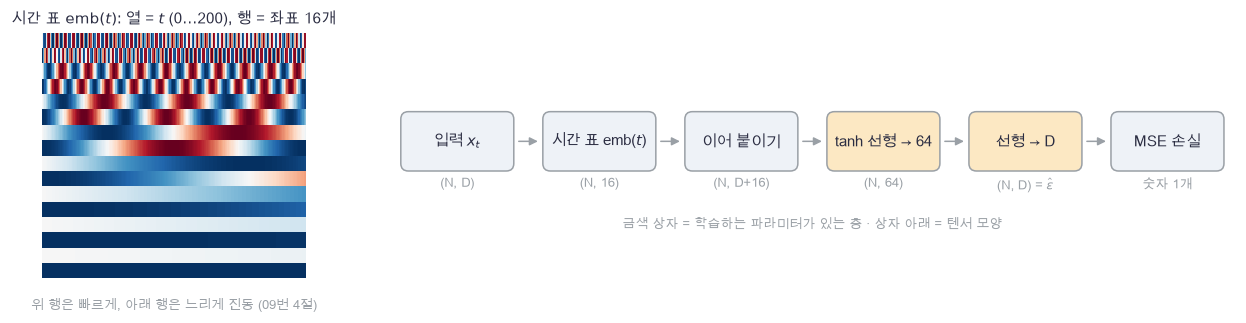

In [36]:
plot_denoiser_blocks(embed_table, denoiser_blocks, param_blocks=(3, 4))

🔍 **확인** · 왼쪽 표에서 위쪽 행은 $t$에 따라 빠르게 파랑·빨강을 오가고 아래쪽 행은 거의 변하지 않습니다. 진동수가 다른 좌표를 겹쳐 놓았기 때문에 시각마다 다른 무늬가 생깁니다. 이웃한 $t=1,2$의 거리는 작고 멀리 떨어진 $t=1,200$의 거리는 큽니다.
오른쪽 흐름에서 금색 상자 둘만 학습하는 층이고, 시간 표와 이어 붙이기는 파라미터가 없습니다. 입력 폭이 $D+16$이라는 것만 03번의 MLP와 다릅니다.

아래 구현은 시간 표, 모델의 forward·backward, MSE 손실, Adam 갱신, 그리고 학습 루프입니다.

In [37]:
def time_embedding(t, E):
    """09번 4절의 sinusoidal 표를 시각에 적용: emb(t)[2i] = sin(t/10000^(2i/E)), emb(t)[2i+1] = cos(·).
    t: (N,) 정수 또는 숫자 하나, E: 짝수 폭 → (N, E)."""
    assert E % 2 == 0, "sin·cos 쌍을 두려면 폭 E 가 짝수여야 합니다"
    times = np.asarray(t, dtype=float).reshape(-1, 1)                 # (N, 1)
    even = np.arange(0, E, 2)[None, :]                                # (1, E/2): 짝수 좌표 번호
    angles = times / (10000 ** (even / E))                            # (N, E/2)
    table = np.empty((len(times), E))
    table[:, 0::2], table[:, 1::2] = np.sin(angles), np.cos(angles)
    return table

In [38]:
def init_denoiser(D, E, hidden, seed):
    """잡음 예측 모델 파라미터: W1 (D+E, hidden), b1 (hidden,), W2 (hidden, D), b2 (D,). 표준편차 1/√입력 (03번 4절의 Glorot 초기화를 tanh 한 층에 맞게 단순화한 것)."""
    rng_init = np.random.default_rng(seed)
    return {"W1": rng_init.normal(size=(D + E, hidden)) / np.sqrt(D + E), "b1": np.zeros(hidden),
            "W2": rng_init.normal(size=(hidden, D)) / np.sqrt(hidden), "b2": np.zeros(D)}


def denoiser_forward(x_t, t, p):
    """forward: U = [x_t, emb(t)], A = tanh(U W1 + b1), ε̂ = A W2 + b2.
    x_t: (N, D), t: (N,) 정수 → (eps_hat: (N, D), cache: (U, A))."""
    # 쓰는 것: time_embedding (4절)
    E = p["W1"].shape[0] - x_t.shape[1]                               # 시간 표의 폭 = 입력 폭 − 데이터 차원
    U = np.concatenate([x_t, time_embedding(t, E)], axis=1)           # (N, D+E): 좌표 축으로 이어 붙임
    A = np.tanh(U @ p["W1"] + p["b1"])                                # (N, hidden)
    return A @ p["W2"] + p["b2"], (U, A)

In [39]:
def denoiser_backward(d_eps, cache, p):
    """backward (03번 5절): dW2 = Aᵀ dε̂, db2 = Σ dε̂, dA = dε̂ W2ᵀ, dZ = dA ⊙ (1 − A²), dW1 = Uᵀ dZ, db1 = Σ dZ.
    d_eps: (N, D), cache: denoiser_forward 의 것 → grads: p 와 같은 키의 사전."""
    U, A = cache
    dA = d_eps @ p["W2"].T                                            # (N, hidden)
    dZ = dA * (1 - A ** 2)                                            # tanh 의 도함수 1 − A²
    return {"W1": U.T @ dZ, "b1": dZ.sum(axis=0), "W2": A.T @ d_eps, "b2": d_eps.sum(axis=0)}


def mse_loss(eps_hat, eps):
    """단순화 손실 J = mean_n ‖ε̂_n − ε_n‖² 와 출력 기울기 ∂J/∂ε̂ = 2(ε̂ − ε)/N.
    eps_hat, eps: (N, D) → (J: 숫자, d_eps: (N, D))."""
    residual = eps_hat - eps                                          # (N, D): 예측 − 정답
    return float(np.mean(np.sum(residual ** 2, axis=1))), 2 * residual / len(eps_hat)

In [40]:
def adam_step(p, grads, state, step, lr):
    """Adam 갱신 (04번 6절)을 파라미터 사전의 모든 배열에. p 를 제자리에서 바꾸고 state 의 (m, v)를 갱신합니다."""
    for key in p:
        m, v = state[key]
        m = 0.9 * m + 0.1 * grads[key]                                # 1차 모멘트
        v = 0.999 * v + 0.001 * grads[key] ** 2                       # 2차 모멘트
        p[key] -= lr * (m / (1 - 0.9 ** step)) / (np.sqrt(v / (1 - 0.999 ** step)) + 1e-8)   # 편향 보정 뒤 갱신
        state[key] = (m, v)

In [41]:
def train_denoiser(X0, alpha_bar, steps, seed, hidden=64, embed=16, batch=256, lr=3e-3):
    """스텝마다 미니배치 x₀ 를 뽑고, 시각 t 를 1…T 에서 고르게 뽑고, 새 ε 으로 x_t 를 만들어 ε 을 맞히게 합니다 (01b번 4절의 루프).
    X0: (N, D) 깨끗한 데이터 → (p: 파라미터 사전, history: 스텝별 손실 (steps,))."""
    # 쓰는 것: init_denoiser, denoiser_forward, denoiser_backward, mse_loss, adam_step (4절) · q_sample (1절)
    last = len(alpha_bar) - 1                                         # T (스케줄 배열의 마지막 번호)
    p = init_denoiser(X0.shape[1], embed, hidden, seed)
    state = {key: (np.zeros_like(value), np.zeros_like(value)) for key, value in p.items()}   # Adam 상태 (m, v)
    rng_train = np.random.default_rng(seed + 1)
    history = []
    for step in range(1, steps + 1):
        X_batch = X0[rng_train.choice(len(X0), batch, replace=False)]  # (batch, D): 겹치지 않게 뽑은 미니배치
        t = rng_train.integers(1, last + 1, size=batch)                # (batch,): 스텝마다 고르게 뽑은 시각
        eps = rng_train.normal(size=X_batch.shape)                     # (batch, D): 새 잡음
        eps_hat, cache = denoiser_forward(q_sample(X_batch, t, eps, alpha_bar), t, p)
        loss, d_eps = mse_loss(eps_hat, eps)
        adam_step(p, denoiser_backward(d_eps, cache, p), state, step, lr)
        history.append(loss)
    return p, np.array(history)

In [42]:
# 쓰는 것: embed_table, embed_E (4절 계산 셀) · T (1절 계산 셀) · time_embedding, mse_loss (4절)
np.testing.assert_allclose(time_embedding(np.arange(T + 1), embed_E), embed_table)   # 검산: 위 그림의 시간 표와 같음
np.testing.assert_allclose(time_embedding(0, 4), [[0., 1., 0., 1.]])                 # 검산: t = 0 이면 sin 0 = 0, cos 0 = 1
hand_eps_hat = np.array([[0.5, -1.0], [0.0, 2.0]])
hand_eps_true = np.array([[1.0, 1.0], [0.0, 0.0]])
hand_loss, hand_d = mse_loss(hand_eps_hat, hand_eps_true)
np.testing.assert_allclose(hand_loss, 4.125)                                         # 검산: 손계산 (4.25 + 4)/2
np.testing.assert_allclose(hand_d, [[-0.5, -2.0], [0.0, 2.0]])                        # 검산: 손계산 2(ε̂ − ε)/2 = 잔차
print("시간 표 일치 · 손계산 손실", hand_loss, "· 출력 기울기\n", hand_d)

시간 표 일치 · 손계산 손실 4.125 · 출력 기울기
 [[-0.5 -2. ]
 [ 0.   2. ]]


In [43]:
# 쓰는 것: denoiser_forward, denoiser_backward, mse_loss, init_denoiser (4절)
probe_p = init_denoiser(2, 8, 8, 344)                                 # 작은 2차원 모델 (은닉 8, 시간 표 8)
probe_rng = np.random.default_rng(345)
probe_xt = probe_rng.normal(size=(5, 2))                              # (5, 2): 검사용 x_t
probe_eps = probe_rng.normal(size=(5, 2))                             # (5, 2): 검사용 정답 ε
probe_t = np.array([3, 50, 120, 200, 1])                              # (5,): 표본마다 다른 시각
probe_hat, probe_cache = denoiser_forward(probe_xt, probe_t, probe_p)
probe_grads = denoiser_backward(mse_loss(probe_hat, probe_eps)[1], probe_cache, probe_p)


def probe_scalar():
    """검사기용: 현재 파라미터의 MSE 손실 (같은 입력·시각·정답)."""
    return mse_loss(denoiser_forward(probe_xt, probe_t, probe_p)[0], probe_eps)[0]


probe_errors = {key: rel_error(probe_grads[key], numerical_gradient(probe_scalar, value)) for key, value in probe_p.items()}
assert max(probe_errors.values()) < 1e-6, "네 파라미터의 기울기가 중심차분과 1e−6 안에서 같아야 합니다"
print("잡음 예측 모델 gradcheck 최대 상대오차:", max(probe_errors.values()))

잡음 예측 모델 gradcheck 최대 상대오차: 6.768414202167368e-10


🔍 **확인** · 표본마다 다른 시각을 준 경우에도 네 파라미터의 기울기가 중심차분과 $10^{-6}$ 안에서 맞습니다. 손계산 손실 $4.125$와 출력 기울기도 맞습니다. 이제 1차원 혼합 데이터 4,000개로 3,000스텝 학습합니다.
평가는 손실이 아니라 **닫힌식 $\epsilon^*$와의 거리** $\mathbb E\|\hat\epsilon-\epsilon^*\|^2$로 합니다. 학습용 작은 문제의 성능이며 실제 벤치마크로 읽지 마세요.

In [44]:
# 쓰는 것: T, alpha_bar (1절 계산 셀) · mix_sample (📎 혼합 셀) · q_sample, optimal_eps (1·3절) · train_denoiser, init_denoiser, denoiser_forward (4절)
train_x0 = mix_sample(4000, np.random.default_rng(34))[:, None]       # (4000, 1): 1차원 학습 데이터
denoiser_p, denoiser_history = train_denoiser(train_x0, alpha_bar, 3000, 340)
denoiser_p0 = init_denoiser(1, 16, 64, 340)                           # 학습 전 파라미터 (학습과 같은 seed)
eval_ts = np.arange(4, T + 1, 4)                                      # (50,): 오차를 잴 시각
eval_x0 = mix_sample(2000, np.random.default_rng(346))[:, None]       # (2000, 1): 평가용 표본
eval_before, eval_after = [], []
for t in eval_ts:
    eps = np.random.default_rng(1000 + t).normal(size=eval_x0.shape)  # 시각마다 고정된 잡음
    x_t = q_sample(eval_x0, t, eps, alpha_bar)                        # (2000, 1)
    star = optimal_eps(x_t[:, 0], t, alpha_bar)[:, None]              # (2000, 1): 닫힌식 최적 예측
    times = np.full(len(x_t), t)
    eval_before.append(float(np.mean((denoiser_forward(x_t, times, denoiser_p0)[0] - star) ** 2)))
    eval_after.append(float(np.mean((denoiser_forward(x_t, times, denoiser_p)[0] - star) ** 2)))
assert np.all(np.array(eval_after) < np.array(eval_before)), "모든 시각에서 학습 뒤 오차가 학습 전보다 작아야 합니다"
assert np.mean(eval_after) < np.mean(eval_before) / 20, "평균 오차가 학습 전의 1/20 아래여야 합니다"
print(f"MSE 손실 {denoiser_history[:100].mean():.4f} → {denoiser_history[-200:].mean():.4f} (0 으로 가지 않음)")
print(f"ε* 와의 평균 제곱거리: 학습 전 {np.mean(eval_before):.4f} → 학습 후 {np.mean(eval_after):.4f} · 학습 후 최댓값 {max(eval_after):.4f}")

MSE 손실 0.8680 → 0.7107 (0 으로 가지 않음)
ε* 와의 평균 제곱거리: 학습 전 0.5015 → 학습 후 0.0047 · 학습 후 최댓값 0.0131


In [45]:
# 쓰는 것: target_x, target_ts, target_pdfs, target_eps_stars (3절 계산 셀) · denoiser_forward (4절) · denoiser_p0, denoiser_p (4절 학습 셀)
learned_before, learned_after = [], []
for t in target_ts:
    times = np.full(len(target_x), t)
    learned_before.append(denoiser_forward(target_x[:, None], times, denoiser_p0)[0][:, 0])   # (801,): 학습 전 ε̂
    learned_after.append(denoiser_forward(target_x[:, None], times, denoiser_p)[0][:, 0])     # (801,): 학습 후 ε̂
print("곡선 준비:", len(learned_after), "개 시각 ×", learned_after[0].shape)

곡선 준비: 3 개 시각 × (801,)


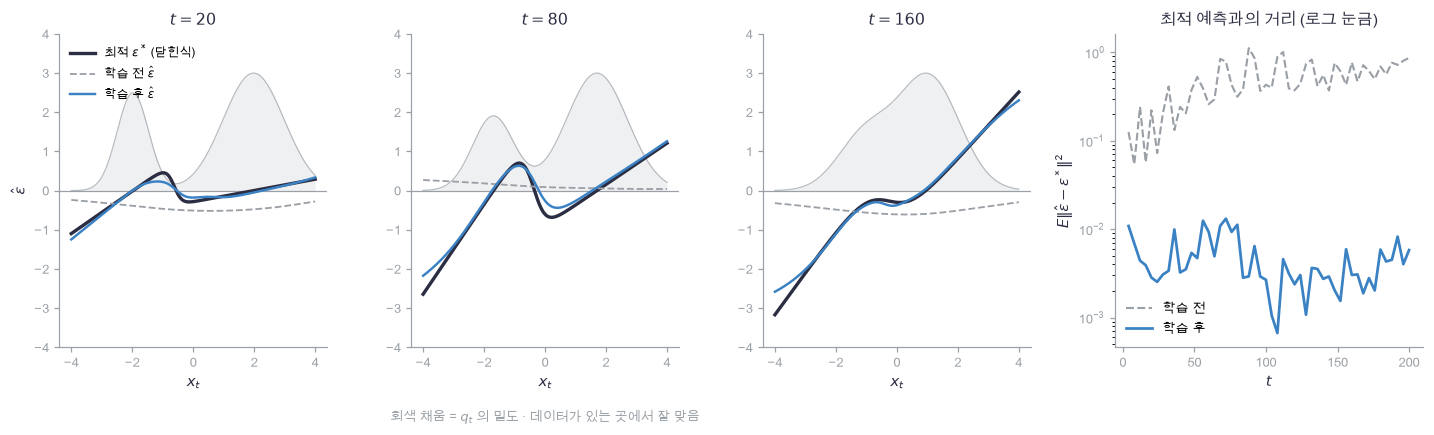

In [46]:
plot_learned_eps(target_x, target_ts, target_pdfs, target_eps_stars, learned_before, learned_after,
                 eval_ts, eval_before, eval_after)

🔍 **확인** · 왼쪽 세 패널에서 학습 후 파란 곡선이 검은 닫힌식 $\epsilon^*$와 데이터가 있는 곳(회색 밀도가 높은 곳)에서 거의 겹칩니다. 회색 점선(학습 전)은 아무 데나 있습니다. 오른쪽 오차 곡선은 로그 눈금에서 학습 전보다 평균 100배쯤 아래입니다($0.5015\to0.0047$).
한 모델이 시각 50개를 모두 맞힙니다. 입력에 시간 표를 붙였기 때문입니다. 다만 배율은 시각마다 달라서, 그림 왼쪽 끝의 작은 $t$에서는 두 곡선이 한 자리밖에 떨어져 있지 않고($t=8$에서 8배) 중간 $t$에서는 세 자리까지 벌어집니다($t=108$에서 1,300배). 시각 50개 중 20개가 100배 아래입니다.

같은 코드로 2차원 혼합도 학습합니다. 입력·출력 차원만 2가 됩니다.

In [47]:
# 쓰는 것: alpha_bar (1절 계산 셀) · mix2_sample, mix2_logpdf (📎 혼합 셀) · q_sample, optimal_eps2 (1·3절) · train_denoiser, init_denoiser, denoiser_forward (4절)
train_X2 = mix2_sample(4000, np.random.default_rng(347))              # (4000, 2): 2차원 학습 데이터
denoiser_p2, denoiser_history2 = train_denoiser(train_X2, alpha_bar, 3000, 348)
field_t = 80
field_xx, field_yy = np.meshgrid(np.linspace(-4, 4, 17), np.linspace(-3, 4, 13))   # (13, 17) 둘: 화살표 격자
field_X = np.column_stack([field_xx.ravel(), field_yy.ravel()])       # (221, 2)
field_star = optimal_eps2(field_X, field_t, alpha_bar)                # (221, 2): 닫힌식 최적 ε
field_hat = denoiser_forward(field_X, np.full(len(field_X), field_t), denoiser_p2)[0]   # (221, 2): 학습한 ε̂
dense_xx, dense_yy = np.meshgrid(np.linspace(-4, 4, 121), np.linspace(-3, 4, 106))      # 등고선용 촘촘한 격자
dense_ab = alpha_bar[field_t]
dense_pdf = np.exp(mix2_logpdf(np.column_stack([dense_xx.ravel(), dense_yy.ravel()]) / np.sqrt(dense_ab),
                               np.sqrt((1 - dense_ab) / dense_ab))).reshape(dense_xx.shape) / dense_ab   # q(x_t): 변수변환의 야코비안 1/ᾱ_t 까지
field_error = float(np.mean(np.sum((field_hat - field_star) ** 2, axis=1)))
field_error0 = float(np.mean(np.sum((denoiser_forward(field_X, np.full(len(field_X), field_t), init_denoiser(2, 16, 64, 348))[0] - field_star) ** 2, axis=1)))
assert field_error < field_error0 / 5, "2차원에서도 학습 뒤 격자 오차가 학습 전의 1/5 아래여야 합니다"
print(f"2차원 MSE 손실 {denoiser_history2[:100].mean():.4f} → {denoiser_history2[-200:].mean():.4f} · t = {field_t} 격자 오차 {field_error0:.4f} → {field_error:.4f}")

2차원 MSE 손실 1.4694 → 1.2080 · t = 80 격자 오차 3.7094 → 0.1298


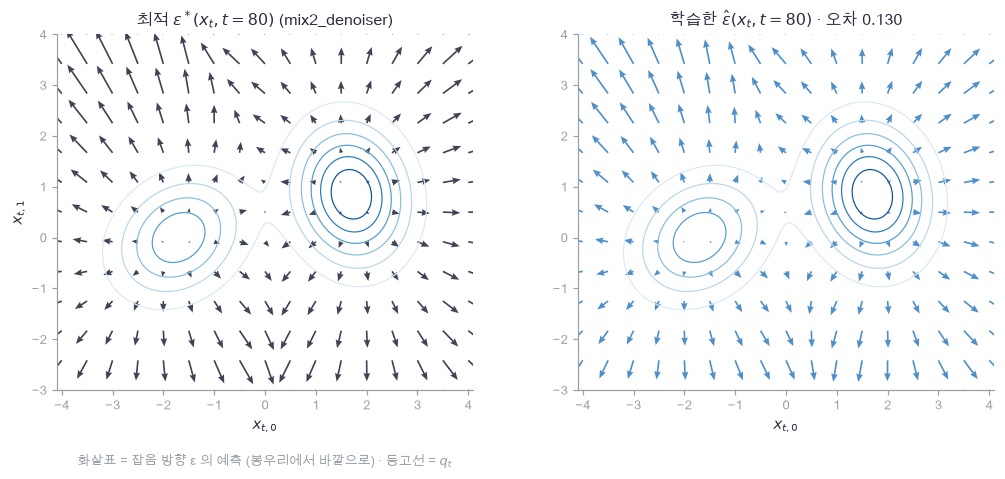

In [48]:
plot_eps_field_2d(dense_xx, dense_yy, dense_pdf, field_X, field_star, field_hat, field_t, field_error)

🔍 **확인** · 왼쪽 검은 화살표(닫힌식)와 오른쪽 파란 화살표(학습 결과)가 등고선 안에서 같은 방향·비슷한 길이입니다. 화살표는 "이 점에 섞인 잡음이 어느 쪽을 향하는가"이고, 봉우리에서 멀수록 길어집니다. 등고선 밖에서는 학습 데이터가 없어 화살표가 덜 정확합니다.

마지막으로 MNIST PCA-32 좌표에서 같은 코드를 돌립니다. 데이터 차원이 32로 커질 뿐 바뀌는 줄이 없습니다. 파라미터는 저장하지 않습니다. 35번이 역과정과 함께 다시 학습합니다.

> **코드** · `np.argmax(조건 배열)`: True가 처음 나오는 번호. 앞 5,000장에서 첫 번째 7을 고를 때 씁니다.

In [49]:
# 쓰는 것: mnist_Z, mnist_y_all (📎 PCA 셀) · alpha_bar (1절 계산 셀) · train_denoiser (4절)
mnist_p, mnist_history = train_denoiser(mnist_Z, alpha_bar, 3000, 349, hidden=256, lr=2e-3)
mnist_seven = int(np.argmax(mnist_y_all[:5000] == 7))                 # 앞 5,000장에서 첫 번째 7 의 번호
print("MNIST 좌표", mnist_Z.shape, "· 32개 좌표 합의 MSE 손실",
      f"{mnist_history[:100].mean():.3f} → {mnist_history[-200:].mean():.3f}", "· 예시로 쓸 7 의 번호", mnist_seven)

MNIST 좌표 (5000, 32) · 32개 좌표 합의 MSE 손실 21.768 → 14.424 · 예시로 쓸 7 의 번호 15


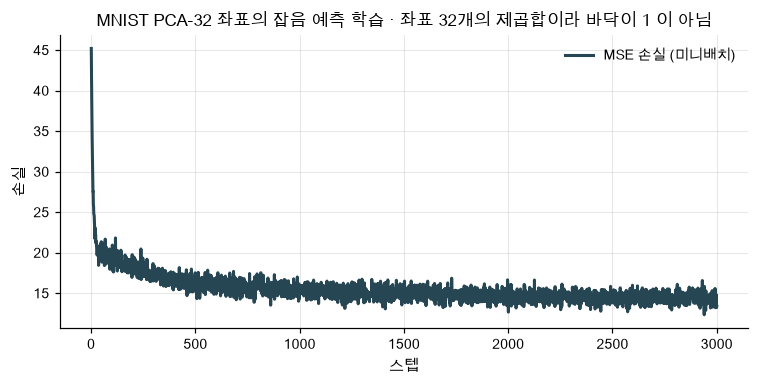

In [50]:
plot_curves(np.arange(1, len(mnist_history) + 1), {"MSE 손실 (미니배치)": mnist_history},
            title="MNIST PCA-32 좌표의 잡음 예측 학습 · 좌표 32개의 제곱합이라 바닥이 1 이 아님", ylabel="손실")

In [51]:
# 쓰는 것: mnist_Z, mnist_seven (4절 MNIST 셀) · decode_pca (📎 PCA 셀) · alpha_bar (1절) · q_sample, denoiser_forward (1·4절)
shot_ts = [25, 100, 175]                                              # 한 번에 되돌리기를 볼 세 시각
shot_rows, shot_model, shot_naive = [], [], []
shot_Z = mnist_Z[:500]                                                # (500, 32): 오차를 잴 좌표들
for t in shot_ts:
    ab = alpha_bar[t]
    eps = np.random.default_rng(2000 + t).normal(size=shot_Z.shape)   # (500, 32)
    Z_t = q_sample(shot_Z, t, eps, alpha_bar)                         # (500, 32): 시각 t 의 좌표
    eps_hat = denoiser_forward(Z_t, np.full(len(Z_t), t), mnist_p)[0]
    Z0_hat = (Z_t - np.sqrt(1 - ab) * eps_hat) / np.sqrt(ab)          # (500, 32): 3절의 한 줄 변환
    shot_model.append(float(np.mean(np.sum((Z0_hat - shot_Z) ** 2, axis=1))))
    shot_naive.append(float(np.mean(np.sum((Z_t / np.sqrt(ab) - shot_Z) ** 2, axis=1))))   # 잡음을 무시하고 신호만 되돌린 것
    images = decode_pca(np.stack([shot_Z[mnist_seven], Z_t[mnist_seven], Z0_hat[mnist_seven]]))
    shot_rows.append((images[0], images[1], images[2]))
assert np.all(np.array(shot_model) < np.array(shot_naive)), "학습한 ε̂ 로 되돌린 x̂₀ 가 잡음을 무시한 x_t/√ᾱ 보다 가까워야 합니다"
print("좌표 복원 제곱거리 (t =", shot_ts, "): 모델", np.round(shot_model, 2), "· 잡음 무시", np.round(shot_naive, 2))

좌표 복원 제곱거리 (t = [25, 100, 175] ): 모델 [ 0.85  7.64 24.01] · 잡음 무시 [  1.06  21.29 119.  ]


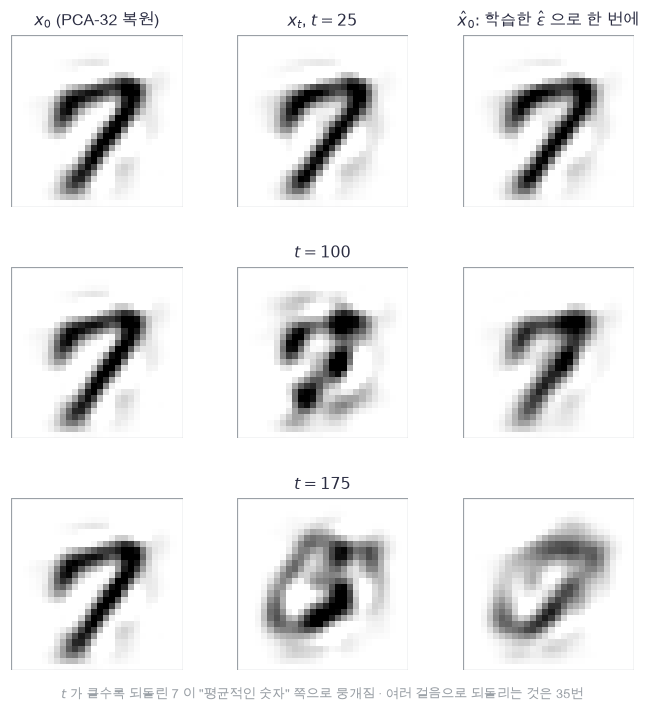

In [52]:
plot_denoised_examples(shot_rows, shot_ts)

🔍 **확인** · 세 시각 모두 학습한 $\hat\epsilon$으로 한 번에 되돌린 $\hat x_0$가 "잡음을 무시하고 신호만 키운" $x_t/\sqrt{\bar\alpha_t}$보다 원본에 가깝고, 시각이 늦어질수록 차이가 벌어집니다. 제곱거리의 비는 $t=25$에서 1.2배, $t=100$에서 2.8배, $t=175$에서 5배입니다($119.0$ 대 $24.0$).
그림에서 $t=25$의 복원은 원본과 거의 같고, $t=100$에서는 획이 굵어진 7, $t=175$에서는 **아예 다른 숫자처럼 보이는 것**이 나옵니다. 잡음이 원본을 지워 버렸으니 모델은 "이 잡음 낀 좌표와 어울리는 평균적인 숫자"를 낼 수밖에 없습니다. 조건부 평균이 여러 가능한 원본의 중간이 되는 것입니다(3절의 $t=160$ 곡선이 완만해진 것과 같은 이야기).
그래서 한 번에 되돌리면 흐릿합니다. **여러 걸음으로 조금씩 되돌리면** 매 걸음 잡음을 다시 섞어 하나의 선명한 그림으로 수렴합니다. 그것이 35번의 역과정입니다.

### ✏️ 연습 4 · 모델 입력 만들기: $x_t$ 옆에 시각 붙이기

잡음 낀 점 `x_t` `(N, D)`와 시각 `t` `(N,)`, 시간 표의 폭 `embed`에서 모델 입력 $U=[\,x_t\;\;\mathrm{emb}(t)\,]$ `(N, D+E)`를 만드는 한 줄을 채우세요. 이 한 줄이 없으면 모델은 지금이 몇 번째 시각인지 모르고, 3절 그림의 세 곡선을 하나로 뭉갠 답을 내게 됩니다.

In [53]:

def exercise_model_input(x_t, t, embed):
    """연습 4: 모델 입력 U = [x_t, emb(t)]. x_t: (N, D), t: (N,) 정수, embed: 시간 표의 폭 E → U: (N, D + E)."""
    assert len(x_t) == len(np.atleast_1d(t)), "표본 수와 시각 수가 같아야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: U = x_t 와 time_embedding(t, embed) 를 좌표 축으로 이어 붙인 (N, D + E)
    ### 힌트: 4절 denoiser_forward 의 한 줄입니다. np.concatenate([...], axis=1) 로 열을 붙입니다.
    raise NotImplementedError
    return U

In [54]:

def check_model_input(candidate):
    """t = 0 의 손계산(emb(0) = [0, 1, 0, 1]), 본문 denoiser_forward 의 캐시로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: probe_xt, probe_t, probe_cache (4절 검산 셀)
    hand = candidate(np.array([[1.0], [2.0]]), np.array([0, 0]), 4)
    assert hand.shape == (2, 5), f"D = 1, E = 4 면 입력은 (2, 5)여야 하는데 {hand.shape} 입니다"
    np.testing.assert_allclose(hand, [[1.0, 0.0, 1.0, 0.0, 1.0], [2.0, 0.0, 1.0, 0.0, 1.0]])   # 검산: emb(0) 은 sin 0 = 0, cos 0 = 1
    np.testing.assert_allclose(candidate(probe_xt, probe_t, 8), probe_cache[0])                 # 검산: 4절 검산 셀의 모델이 만든 입력 U
    print("모델 입력: 손계산 emb(0)·denoiser_forward 의 캐시와 일치합니다.")

run_check(check_model_input, exercise_model_input, hint="U = np.concatenate([x_t, time_embedding(t, embed)], axis=1)")

☐ exercise_model_input: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: U = np.concatenate([x_t, time_embedding(t, embed)], axis=1)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
U = np.concatenate([x_t, time_embedding(t, embed)], axis=1)
```

</details>

## 🔍 5. 같은 오차를 $\epsilon$으로 재느냐 $x_0$로 재느냐: SNR

4절의 손실은 모든 시각을 하나로 섞은 평균이었습니다. 시각별로 나누어 보면 그림이 전혀 다릅니다. 그리고 "어느 $t$가 어려운가"라는 질문의 답은 **무엇으로 재느냐**에 따라 정반대가 됩니다.

> **용어** · **SNR(signal-to-noise ratio, 신호 대 잡음 비)** $\mathrm{SNR}(t)=\bar\alpha_t/(1-\bar\alpha_t)$: 시각 $t$에서 남은 신호의 몫과 잡음의 몫의 비. $t$가 커질수록 단조 감소하고, 1을 지나는 곳이 "신호와 잡음이 반반"인 시각입니다.

3절의 한 줄 변환을 오차에 그대로 적용하면 두 손실이 상수배로 이어집니다.

$$\hat x_0-x_0=\frac{-\sqrt{1-\bar\alpha_t}\,(\hat\epsilon-\epsilon)}{\sqrt{\bar\alpha_t}}
\quad\Longrightarrow\quad
\|\hat x_0-x_0\|^2=\frac{1-\bar\alpha_t}{\bar\alpha_t}\,\|\hat\epsilon-\epsilon\|^2=\frac{\|\hat\epsilon-\epsilon\|^2}{\mathrm{SNR}(t)}.$$

$\epsilon$ 손실에 $1/\mathrm{SNR}(t)$를 곱하면 $x_0$ 손실입니다. $\mathrm{SNR}$이 $t = 2$의 3332.6에서 $t = 200$의 0.152까지 2만 배 넘게 변하므로, 같은 예측을 두 자로 재면 "어려운 $t$"가 뒤바뀝니다. 아래에서 4절의 학습된 모델과 닫힌식 최적 예측($\epsilon^*$)을 시각 100개에서 각각 재 봅니다.

In [55]:
# 쓰는 것: alpha_bar, T (1절 계산 셀) · mix_sample (📎 혼합 셀) · q_sample, optimal_eps (1·3절) · denoiser_forward, denoiser_p (4절)
loss_ts = np.arange(2, T + 1, 2)                                      # (100,): 손실을 잴 시각
loss_rng = np.random.default_rng(350)
loss_x0 = mix_sample(4000, loss_rng)[:, None]                         # (4000, 1): 평가용 표본
loss_eps_model, loss_eps_floor, loss_x0_model, loss_x0_floor, loss_excess = [], [], [], [], []
for t in loss_ts:
    ab = alpha_bar[t]
    eps = loss_rng.normal(size=loss_x0.shape)                         # (4000, 1): 이 시각에 더한 잡음
    x_t = q_sample(loss_x0, t, eps, alpha_bar)
    star = optimal_eps(x_t[:, 0], t, alpha_bar)[:, None]              # (4000, 1): 닫힌식 최적 예측 (손실의 바닥)
    hat = denoiser_forward(x_t, np.full(len(x_t), t), denoiser_p)[0]  # (4000, 1): 학습한 모델
    loss_eps_model.append(float(np.mean(np.sum((hat - eps) ** 2, axis=1))))
    loss_eps_floor.append(float(np.mean(np.sum((star - eps) ** 2, axis=1))))
    loss_excess.append(float(np.mean(np.sum((hat - star) ** 2, axis=1))))   # 최적 예측과의 거리 (0 이상)
    x0_from_hat = (x_t - np.sqrt(1 - ab) * hat) / np.sqrt(ab)         # 3절의 한 줄 변환
    x0_from_star = (x_t - np.sqrt(1 - ab) * star) / np.sqrt(ab)
    loss_x0_model.append(float(np.mean(np.sum((x0_from_hat - loss_x0) ** 2, axis=1))))
    loss_x0_floor.append(float(np.mean(np.sum((x0_from_star - loss_x0) ** 2, axis=1))))
print("ε 손실 (t = 2, 100, 200):", np.round(np.array(loss_eps_model)[[0, 49, 99]], 3),
      "· x₀ 손실:", np.round(np.array(loss_x0_model)[[0, 49, 99]], 3))

ε 손실 (t = 2, 100, 200): [1.045 0.675 0.397] · x₀ 손실: [0.    0.445 2.609]


In [56]:
# 쓰는 것: loss_ts, loss_eps_model, loss_eps_floor, loss_x0_model, loss_x0_floor (5절 계산 셀) · alpha_bar (1절 계산 셀)
loss_eps_model, loss_eps_floor = np.array(loss_eps_model), np.array(loss_eps_floor)
loss_x0_model, loss_x0_floor = np.array(loss_x0_model), np.array(loss_x0_floor)
loss_excess = np.array(loss_excess)                                   # (100,): 시각별 ‖ε̂ − ε*‖²
loss_snr = alpha_bar[loss_ts] / (1 - alpha_bar[loss_ts])              # (100,): SNR(t) = ᾱ_t/(1 − ᾱ_t)
bin_edges = [0, 50, 100, 150, 200]                                    # t 를 네 구간으로
bin_labels = [f"{lo + 1}–{hi}" for lo, hi in zip(bin_edges[:-1], bin_edges[1:])]
bin_model, bin_floor = [], []
for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
    inside = (loss_ts > lo) & (loss_ts <= hi)                         # (100,) bool: 이 구간의 시각
    bin_model.append(float(loss_eps_model[inside].mean()))
    bin_floor.append(float(loss_eps_floor[inside].mean()))
print("SNR(2) =", round(float(loss_snr[0]), 1), "· SNR(100) =", round(float(loss_snr[49]), 3), "· SNR(200) =", round(float(loss_snr[99]), 3))
print("구간별 ε 손실 (모델):", np.round(bin_model, 3), "· 바닥:", np.round(bin_floor, 3))

SNR(2) = 3332.6 · SNR(100) = 1.516 · SNR(200) = 0.152
구간별 ε 손실 (모델): [0.939 0.757 0.648 0.495] · 바닥: [0.931 0.749 0.645 0.491]


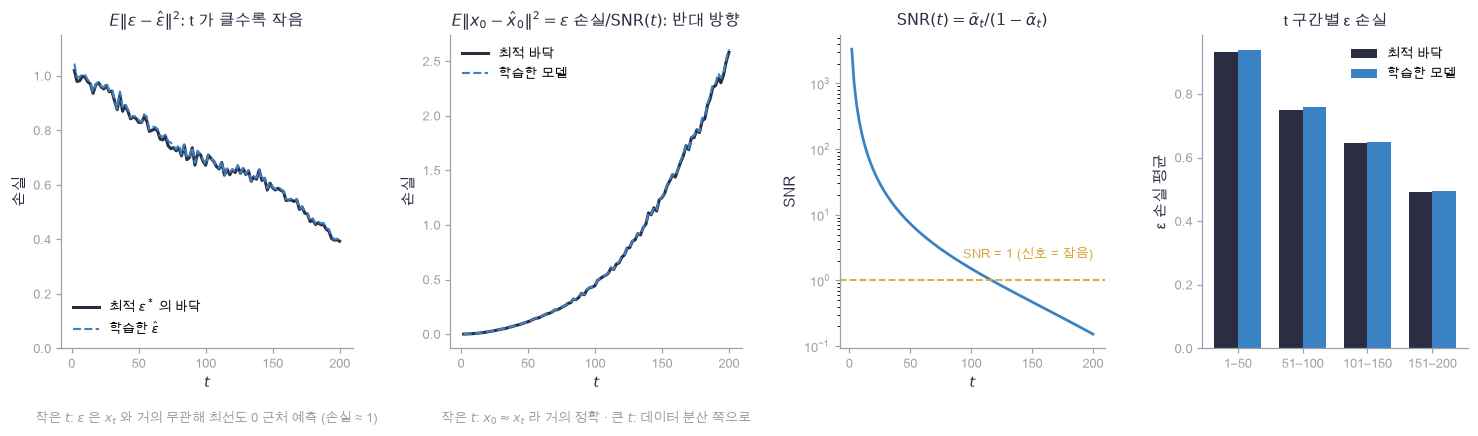

In [57]:
plot_loss_by_t(loss_ts, loss_eps_model, loss_eps_floor, loss_x0_model, loss_x0_floor, loss_snr,
               bin_labels, bin_model, bin_floor)

🔍 **확인** · 왼쪽 $\epsilon$ 손실은 $t$가 커질수록 **작아집니다.** $t$가 작으면 $x_t\approx x_0$이고 잡음은 작은 흔들림일 뿐이라, $x_t$를 보아도 그 잡음이 무엇이었는지 거의 알 수 없어 최선을 다해도 손실이 1(= 잡음의 분산) 근처입니다. $t$가 크면 $x_t$가 거의 잡음 그 자체라 $\epsilon$을 잘 맞힙니다.
가운데 $x_0$ 손실은 정확히 반대입니다. $t$가 작으면 원본이 거의 그대로 보여 손실이 0에 가깝고, $t$가 크면 원본이 거의 지워져 데이터 분산 4.14의 60%쯤인 2.58까지 커집니다 ($\bar\alpha_T = 0.13$이라 아직 신호가 조금 남아 분산 전체만큼은 아닙니다). 두 그림은 같은 예측을 잰 것이며, 오른쪽 $\mathrm{SNR}(t)$ 곡선이 둘 사이의 환산 비율입니다.
맨 오른쪽 막대에서 학습한 모델(파랑)이 최적 바닥(검정)보다 아주 조금 위에 있습니다. 네 구간 모두 바닥에 거의 닿았습니다. 다만 이것은 3,000스텝짜리 작은 학습이라, 시각별 최댓값 $\max_t E\|\hat\epsilon-\epsilon^*\|^2$는 학습 seed에 따라 0.017에서 0.06 사이에서 흔들립니다 (아래 검산의 임계값 0.1은 그 흔들림을 덮는 값입니다). 이 "어느 $t$에 얼마나 무게를 둘 것인가"가 바로 손실 가중치 문제이고, 35b번의 EDM이 다루는 주제입니다. DDPM의 단순화 손실은 $\epsilon$ 자로 재고 모든 $t$에 같은 무게를 주는 선택입니다.

In [58]:
# 쓰는 것: loss_eps_model, loss_eps_floor, loss_x0_model, loss_x0_floor, loss_excess, loss_snr (5절 계산 셀·구간 셀)
np.testing.assert_allclose(loss_x0_model, loss_eps_model / loss_snr, rtol=1e-10)   # 검산: ‖x̂₀ − x₀‖² = ‖ε̂ − ε‖²/SNR
np.testing.assert_allclose(loss_x0_floor, loss_eps_floor / loss_snr, rtol=1e-10)   # 검산: 바닥도 같은 환산
decompose = np.abs((loss_eps_model - loss_eps_floor) - loss_excess)   # (100,): 손실 분해가 얼마나 맞는지
assert np.max(loss_excess) < 0.1, "학습한 모델이 어느 시각에서도 최적 예측과 0.1 이상 떨어지지 않아야 합니다 (seed 마다 0.017–0.06 사이에서 흔들림)"
assert np.max(decompose) < 0.03, "표본 4,000개의 교차항 오차 안에서 ‖ε̂−ε‖² = ‖ε*−ε‖² + ‖ε̂−ε*‖² 가 성립해야 합니다"
assert loss_eps_floor[0] > loss_eps_floor[-1], "ε 손실의 바닥은 t 가 커질수록 작아져야 합니다"
assert loss_x0_floor[0] < loss_x0_floor[-1], "x₀ 손실의 바닥은 t 가 커질수록 커져야 합니다"
print(f"두 자의 환산 ‖x̂₀ − x₀‖² = ‖ε̂ − ε‖²/SNR 이 1e−10 안에서 성립 · 최적 예측과의 최대 거리 {np.max(loss_excess):.4f} · 손실 분해의 최대 오차 {np.max(decompose):.4f}")
print(f"ε 손실 바닥: t = 2 에서 {loss_eps_floor[0]:.3f} → t = 200 에서 {loss_eps_floor[-1]:.3f} · x₀ 손실 바닥: {loss_x0_floor[0]:.4f} → {loss_x0_floor[-1]:.3f}")

두 자의 환산 ‖x̂₀ − x₀‖² = ‖ε̂ − ε‖²/SNR 이 1e−10 안에서 성립 · 최적 예측과의 최대 거리 0.0186 · 손실 분해의 최대 오차 0.0097
ε 손실 바닥: t = 2 에서 1.020 → t = 200 에서 0.393 · x₀ 손실 바닥: 0.0003 → 2.580


🔍 **확인** · 두 손실이 $\mathrm{SNR}(t)$ 배만큼 정확히 이어집니다($10^{-10}$ 안). 손실은 $\mathbb E\|\hat\epsilon-\epsilon\|^2=\underbrace{\mathbb E\|\epsilon^*-\epsilon\|^2}_{\text{바닥}}+\underbrace{\mathbb E\|\hat\epsilon-\epsilon^*\|^2}_{\text{모델의 몫}}$로 나뉘고(교차항의 기댓값이 0), 표본 4,000개에서 이 분해가 $0.03$ 안에서 맞습니다. 모델의 몫은 어느 시각에서도 $0.05$ 아래입니다.
$\epsilon$ 자의 바닥은 $t=2$의 $1.02$에서 $t=200$의 $0.39$로 내려가고, $x_0$ 자의 바닥은 $0.0003$에서 $2.58$로 반대로 올라갑니다.

## ✏️ 6. 직접 채워서 확인합니다

연습은 코딩 테스트처럼 **함수 뼈대가 미리 있고 핵심 한두 줄만 비어 있습니다.**
`raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓴 뒤, 셀을 실행하고 바로 아래 검사 셀을 실행하세요.
아직 채우지 않았으면 안내문만 나오고, 값이 다르면 "손계산과 다릅니다"가 나옵니다. 막히면 그 아래 "정답 보기"를 펼칩니다.

### 연습 A · 한 번에 $t$ 시점으로 가기 (1절)

깨끗한 데이터 `x0` `(N, D)`, 표본마다의 시각 `t` `(N,)`, 잡음 `eps` `(N, D)`에서 $x_t=\sqrt{\bar\alpha_t}x_0+\sqrt{1-\bar\alpha_t}\epsilon$ 한 줄을 채우세요. 표본마다의 $\bar\alpha_t$를 `(N, 1)`로 세워 둔 `ab`는 써 두었습니다.

In [59]:
def exercise_q_sample(x0, t, eps, alpha_bar_values):
    """연습 A: 닫힌식 전방 샘플. x0, eps: (N, D), t: (N,) 정수, alpha_bar_values: (T+1,) → x_t: (N, D)."""
    assert x0.shape == eps.shape, "데이터와 잡음은 같은 (N, D) 모양이어야 합니다"
    ab = alpha_bar_values[np.asarray(t)].reshape(-1, 1)              # (N, 1): 표본마다의 ᾱ_t
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: x_t = √ab × x0 + √(1 − ab) × eps (모양 (N, D))
    ### 힌트: 1절 q_sample 의 마지막 한 줄입니다. np.sqrt(ab) 와 np.sqrt(1 - ab) 가 (N, 1) 이라 좌표 축에 브로드캐스팅됩니다.
    raise NotImplementedError
    return x_t

In [60]:
def check_q_sample(candidate):
    """3절 손계산(ᾱ = 0.64, x₀ = 1, ε = 0.5 → 1.1), 본문 q_sample, 분산이 1 − ᾱ_t 인지로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: alpha_bar, T (1절 계산 셀) · q_sample (1절)
    hand_bar = np.array([1.0, 0.64])                                 # 장난감 스케줄: ᾱ₁ = 0.64
    np.testing.assert_allclose(candidate(np.array([[1.0]]), [1], np.array([[0.5]]), hand_bar), [[1.1]])   # 검산: 손계산 0.8 + 0.3
    x0_c = np.random.default_rng(601).normal(size=(6, 3))
    eps_c = np.random.default_rng(602).normal(size=(6, 3))
    t_c = np.array([1, 7, 40, 90, 150, 200])
    np.testing.assert_allclose(candidate(x0_c, t_c, eps_c, alpha_bar), q_sample(x0_c, t_c, eps_c, alpha_bar))   # 검산: 본문 q_sample 과 같음
    many = candidate(np.zeros((40000, 1)), np.full(40000, 150), np.random.default_rng(603).normal(size=(40000, 1)), alpha_bar)
    assert abs(many.var() - (1 - alpha_bar[150])) < 0.02, "x₀ = 0 이면 x_t 의 분산이 1 − ᾱ_t 여야 합니다"
    print("닫힌식 전방 샘플: 손계산·q_sample·분산 1 − ᾱ_t 와 일치합니다.")

run_check(check_q_sample, exercise_q_sample, hint="x_t = np.sqrt(ab) * x0 + np.sqrt(1 - ab) * eps")

☐ exercise_q_sample: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: x_t = np.sqrt(ab) * x0 + np.sqrt(1 - ab) * eps


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
x_t = np.sqrt(ab) * x0 + np.sqrt(1 - ab) * eps
```

</details>

### ✏️ 연습 B · posterior 평균의 두 계수 (2절)

시각 `t`, 스케줄 `beta_values`·`alpha_bar_values`에서 $\tilde\mu_t=c_0x_0+c_tx_t$의 두 계수를 만드는 두 줄을 채우세요. $\bar\alpha_t$와 $\bar\alpha_{t-1}$은 `ab`, `ab_prev`로 써 두었습니다. 분산 $\tilde\beta_t$는 절 연습 2에서 이미 다루었으므로 여기서는 평균의 계수만 봅니다.

In [61]:
def exercise_posterior_mean_coefs(t, beta_values, alpha_bar_values):
    """연습 B: c₀(t) = √ᾱ_{t−1} β_t/(1 − ᾱ_t), c_t(t) = √α_t (1 − ᾱ_{t−1})/(1 − ᾱ_t). t: 정수 또는 배열 → (c0, ct)."""
    assert np.all(np.asarray(t) >= 1), "t 는 1 이상이어야 합니다"
    ab, ab_prev = alpha_bar_values[t], alpha_bar_values[np.asarray(t) - 1]   # ᾱ_t 와 ᾱ_{t−1}
    alpha_t = 1 - beta_values[t]                                     # α_t = 1 − β_t
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: c0 = √ab_prev × β_t / (1 − ab), ct = √alpha_t × (1 − ab_prev) / (1 − ab)
    ### 힌트: 2절 posterior_coefficients 의 두 줄입니다. β_t 는 beta_values[t] 입니다.
    raise NotImplementedError
    return c0, ct

In [62]:
def check_posterior_mean_coefs(candidate):
    """2절 손계산(장난감 스케줄 t = 2), 그림의 곡선, 격자 적분 평균으로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: toy_beta, toy_alpha_bar (1절 검산 셀) · beta, alpha_bar (1절 계산 셀) · post_ts, post_c0, post_ct, post_t, post_x0, post_xt, post_grid_mean (2절 계산 셀)
    np.testing.assert_allclose(candidate(2, toy_beta, toy_alpha_bar), [0.677631, 0.319438], atol=1e-6)   # 검산: 손계산 √0.9×0.2/0.28, √0.8×0.1/0.28
    np.testing.assert_allclose(candidate(1, toy_beta, toy_alpha_bar), [1.0, 0.0], atol=1e-12)            # 검산: t = 1 이면 되묻기가 곧 x₀
    c0_all, ct_all = candidate(post_ts, beta, alpha_bar)
    np.testing.assert_allclose([c0_all, ct_all], [post_c0, post_ct])                                     # 검산: 2절 그림의 두 곡선
    c0_one, ct_one = candidate(post_t, beta, alpha_bar)
    assert abs(c0_one * post_x0 + ct_one * post_xt - post_grid_mean) < 1e-9, "격자로 적분한 posterior 평균과 1e−9 안에서 같아야 합니다"
    print("posterior 평균의 두 계수: 손계산·그림의 곡선·격자 적분과 일치합니다.")

run_check(check_posterior_mean_coefs, exercise_posterior_mean_coefs,
          hint="c0 = np.sqrt(ab_prev) * beta_values[t] / (1 - ab) · ct = np.sqrt(alpha_t) * (1 - ab_prev) / (1 - ab)")

☐ exercise_posterior_mean_coefs: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: c0 = np.sqrt(ab_prev) * beta_values[t] / (1 - ab) · ct = np.sqrt(alpha_t) * (1 - ab_prev) / (1 - ab)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
c0 = np.sqrt(ab_prev) * beta_values[t] / (1 - ab)
ct = np.sqrt(alpha_t) * (1 - ab_prev) / (1 - ab)
```

</details>

### ✏️ 연습 C · 혼합에서 최적 $\epsilon$ 예측 (3절)

잡음 낀 점 `x_t` `(N,)`와 시각 `t`에서 $\epsilon^*(x_t)=\dfrac{x_t-\sqrt{\bar\alpha_t}\,\mathbb E[x_0\mid x_t]}{\sqrt{1-\bar\alpha_t}}$를 만듭니다. $\bar\alpha_t$와 $\sigma_t=\sqrt{(1-\bar\alpha_t)/\bar\alpha_t}$는 써 두었으니, 23번의 `mix_denoiser`로 $\mathbb E[x_0\mid x_t]$를 구하는 줄과 $\epsilon^*$로 바꾸는 줄, 두 줄을 채우세요.

In [63]:
def exercise_optimal_eps(x_t, t, alpha_bar_values):
    """연습 C: 혼합에서 최적 잡음 예측 ε*(x_t). x_t: (N,), t: 정수, alpha_bar_values: (T+1,) → (N,)."""
    assert x_t.ndim == 1, "이 연습은 1차원 x_t (N,) 만 다룹니다"
    ab = alpha_bar_values[t]                                         # ᾱ_t
    sigma_t = np.sqrt((1 - ab) / ab)                                 # σ_t: 신호를 1 로 맞췄을 때의 잡음 크기
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: x0_hat = mix_denoiser 로 구한 E[x₀|x_t] (모양 (N,)), eps_star = (x_t − √ab × x0_hat)/√(1 − ab) (모양 (N,))
    ### 힌트: 3절 optimal_eps 의 두 줄입니다. mix_denoiser 에는 x_t 가 아니라 x_t/√ab 를 넣습니다.
    raise NotImplementedError
    return eps_star

In [64]:
def check_optimal_eps(candidate):
    """3절 그림의 ε* 곡선과 score 관계 −ε*/√(1−ᾱ) = ∇ log q(x_t) 로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: alpha_bar (1절 계산 셀) · target_x, target_ts, target_eps_stars (3절 계산 셀) · q_t_score (3절)
    for t, eps_star in zip(target_ts, target_eps_stars):
        np.testing.assert_allclose(candidate(target_x, t, alpha_bar), eps_star)     # 검산: 3절 그림의 곡선
    probe = np.random.default_rng(611).uniform(-3, 3, size=5)
    for t in [30, 120]:
        from_eps = -candidate(probe, t, alpha_bar) / np.sqrt(1 - alpha_bar[t])
        np.testing.assert_allclose(from_eps, q_t_score(probe, t, alpha_bar), atol=1e-12)   # 검산: 따로 유도한 닫힌식 score 와 같음
    far = candidate(np.array([12.0]), 150, alpha_bar)
    assert far[0] > 2.0, "데이터에서 아주 먼 점은 거의 전부 잡음이라 ε* 가 크게 나와야 합니다"
    print("최적 ε 예측: 3절 곡선·score 관계와 일치합니다.")

run_check(check_optimal_eps, exercise_optimal_eps,
          hint="x0_hat = mix_denoiser(x_t / np.sqrt(ab), sigma_t) · eps_star = (x_t - np.sqrt(ab) * x0_hat) / np.sqrt(1 - ab)")

☐ exercise_optimal_eps: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: x0_hat = mix_denoiser(x_t / np.sqrt(ab), sigma_t) · eps_star = (x_t - np.sqrt(ab) * x0_hat) / np.sqrt(1 - ab)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
x0_hat = mix_denoiser(x_t / np.sqrt(ab), sigma_t)
eps_star = (x_t - np.sqrt(ab) * x0_hat) / np.sqrt(1 - ab)
```

</details>

### ✏️ 연습 D · 단순화 손실과 출력 기울기 (4절)

예측 `eps_hat` `(N, D)`와 정답 `eps` `(N, D)`에서 $J=\frac1N\sum_n\|\hat\epsilon_n-\epsilon_n\|^2$와 $\partial J/\partial\hat\epsilon=\frac2N(\hat\epsilon-\epsilon)$ 두 줄을 채우세요. 좌표 축은 합, 관측 축은 평균입니다. 잔차는 써 두었습니다.

In [65]:
def exercise_mse_loss(eps_hat, eps):
    """연습 D: 단순화 손실과 출력 기울기. eps_hat, eps: (N, D) → (loss: 숫자, d_eps: (N, D))."""
    assert eps_hat.shape == eps.shape, "예측과 정답은 같은 (N, D) 모양이어야 합니다"
    residual = eps_hat - eps                                         # (N, D): 예측 − 정답
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: loss = residual² 을 좌표 축으로 합한 뒤 관측 축으로 평균한 숫자, d_eps = 2 × residual / N (모양 (N, D))
    ### 힌트: 4절 mse_loss 의 한 줄입니다. np.mean(np.sum(residual ** 2, axis=1)) 이고 N 은 len(eps_hat) 입니다.
    raise NotImplementedError
    return loss, d_eps

In [66]:
def check_mse_loss(candidate):
    """4절 손계산(4.125), 본문 mse_loss, 중심차분으로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: mse_loss (4절)
    loss_hand, d_hand = candidate(np.array([[0.5, -1.0], [0.0, 2.0]]), np.array([[1.0, 1.0], [0.0, 0.0]]))
    np.testing.assert_allclose(loss_hand, 4.125)                                    # 검산: 손계산 (4.25 + 4)/2
    np.testing.assert_allclose(d_hand, [[-0.5, -2.0], [0.0, 2.0]])                   # 검산: 손계산 2 × 잔차 / 2
    hat_c = np.random.default_rng(621).normal(size=(5, 3))
    eps_c = np.random.default_rng(622).normal(size=(5, 3))
    loss_c, d_c = candidate(hat_c, eps_c)
    np.testing.assert_allclose([loss_c], [mse_loss(hat_c, eps_c)[0]])                # 검산: 본문 mse_loss 의 손실
    np.testing.assert_allclose(d_c, mse_loss(hat_c, eps_c)[1])                       # 검산: 본문 mse_loss 의 기울기

    def loss_scalar():
        """검사기용: 후보가 낸 손실값."""
        return float(candidate(hat_c, eps_c)[0])

    assert rel_error(d_c, numerical_gradient(loss_scalar, hat_c)) < 1e-7, "출력 기울기가 중심차분과 1e−7 안에서 같아야 합니다"
    print("단순화 손실과 출력 기울기: 손계산·mse_loss·중심차분과 일치합니다.")

run_check(check_mse_loss, exercise_mse_loss,
          hint="loss = float(np.mean(np.sum(residual ** 2, axis=1))) · d_eps = 2 * residual / len(eps_hat)")

☐ exercise_mse_loss: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: loss = float(np.mean(np.sum(residual ** 2, axis=1))) · d_eps = 2 * residual / len(eps_hat)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
loss = float(np.mean(np.sum(residual ** 2, axis=1)))
d_eps = 2 * residual / len(eps_hat)
```

</details>

### 🔍 완성 예제 · 선형 스케줄을 코사인 스케줄로 바꾸기

1절에서 $\bar\alpha_T=0.13$이라 마지막 시각에도 신호가 남는다고 했습니다. 역과정은 순수 잡음에서 출발하는데 학습은 "신호가 조금 남은 $x_T$"로 했으니 어긋납니다. 코사인 스케줄은 $\bar\alpha_t=\cos^2\!\left(\frac{t/T+s}{1+s}\cdot\frac{\pi}{2}\right)\big/\cos^2\!\left(\frac{s}{1+s}\cdot\frac{\pi}{2}\right)$로 $\bar\alpha$ 자체를 먼저 정하고 $\beta_t=1-\bar\alpha_t/\bar\alpha_{t-1}$을 거꾸로 계산합니다. 그러면 $T$가 얼마든 끝에서 $\bar\alpha_T\approx0$입니다.
바뀌는 것은 스케줄 배열 세 개뿐이고 `q_sample`·`posterior_coefficients`·`train_denoiser`는 한 줄도 바뀌지 않습니다. 같은 seed·같은 스텝 수로 다시 학습해 $\bar\alpha$ 곡선, SNR, 시각별 $\epsilon$ 손실을 비교합니다. 학습용 작은 문제의 결과입니다.

> **코드** · `np.clip(v, 0, 0.999)`: $\beta_t$가 1에 닿으면 $\alpha_t=0$이 되어 나눗셈이 깨지므로 위를 잘라 둡니다 (Nichol·Dhariwal 2021의 관례).

In [67]:
def cosine_schedule(T, s=0.008):
    """코사인 스케줄: ᾱ_t = cos²((t/T + s)/(1 + s) · π/2) 를 먼저 정하고 β_t = 1 − ᾱ_t/ᾱ_{t−1} 을 거꾸로 얻습니다.
    T: 걸음 수 → (beta: (T+1,), alpha: (T+1,), alpha_bar: (T+1,))."""
    f = np.cos((np.arange(T + 1) / T + s) / (1 + s) * np.pi / 2) ** 2  # (T+1,): 원하는 ᾱ 모양
    target = f / f[0]                                                 # ᾱ₀ = 1 이 되게 맞춤
    beta = np.concatenate([[0.0], np.clip(1 - target[1:] / target[:-1], 0, 0.999)])   # 이웃 비율에서 β_t
    alpha = 1 - beta
    return beta, alpha, np.cumprod(alpha)

In [68]:
# 쓰는 것: T, alpha_bar (1절 계산 셀) · train_x0 (4절 학습 셀) · loss_x0, loss_ts, loss_snr, loss_eps_model, loss_eps_floor (5절 계산 셀) · q_sample, optimal_eps (1·3절) · train_denoiser, denoiser_forward (4절)
cos_beta, cos_alpha, cos_alpha_bar = cosine_schedule(T)
cos_snr = cos_alpha_bar[loss_ts] / (1 - cos_alpha_bar[loss_ts])         # (100,): 코사인 스케줄의 SNR(t)
cos_p, cos_history = train_denoiser(train_x0, cos_alpha_bar, 3000, 340)   # 4절과 같은 데이터·seed·스텝 수
cos_rng = np.random.default_rng(351)
cos_model, cos_floor = [], []
for t in loss_ts:
    eps = cos_rng.normal(size=loss_x0.shape)
    x_t = q_sample(loss_x0, t, eps, cos_alpha_bar)
    star = optimal_eps(x_t[:, 0], t, cos_alpha_bar)[:, None]          # 코사인 스케줄의 ᾱ 로 다시 계산한 정답
    hat = denoiser_forward(x_t, np.full(len(x_t), t), cos_p)[0]
    cos_model.append(float(np.mean(np.sum((hat - eps) ** 2, axis=1))))
    cos_floor.append(float(np.mean(np.sum((star - eps) ** 2, axis=1))))
cos_model, cos_floor = np.array(cos_model), np.array(cos_floor)
assert cos_alpha_bar[T] < alpha_bar[T] / 1000, "코사인 스케줄은 끝에서 ᾱ_T 가 선형보다 세 자리 이상 작아야 합니다"
assert cos_floor[-1] < loss_eps_floor[-1], "ᾱ_T 가 작을수록 마지막 시각의 ε 은 더 잘 맞혀집니다"
assert np.max(cos_model - cos_floor) < 0.1, "코사인 스케줄에서도 학습한 모델이 바닥에 가까워야 합니다 (seed 마다 흔들리는 폭을 덮는 임계값)"
print(f"ᾱ_T: 선형 {alpha_bar[T]:.4f} vs 코사인 {cos_alpha_bar[T]:.2e} · 마지막 시각 ε 손실 바닥 {loss_eps_floor[-1]:.3f} → {cos_floor[-1]:.3f}")
print(f"ᾱ_100: 선형 {alpha_bar[100]:.4f} vs 코사인 {cos_alpha_bar[100]:.4f} · 전체 평균 ε 손실 {loss_eps_model.mean():.3f} → {cos_model.mean():.3f}")

ᾱ_T: 선형 0.1322 vs 코사인 6.07e-08 · 마지막 시각 ε 손실 바닥 0.393 → 0.000
ᾱ_100: 선형 0.6025 vs 코사인 0.4938 · 전체 평균 ε 손실 0.710 → 0.591


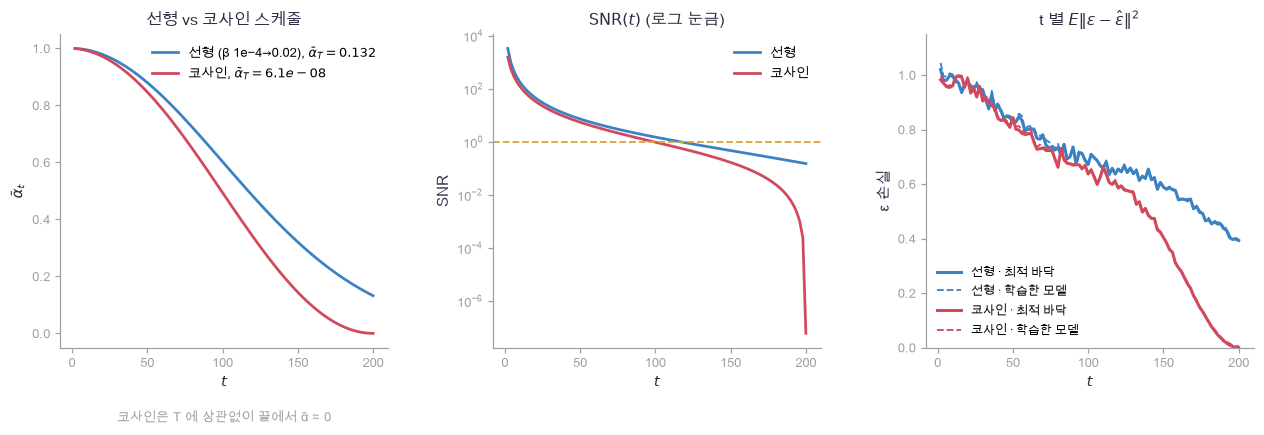

In [69]:
plot_schedule_comparison(loss_ts, alpha_bar[loss_ts], cos_alpha_bar[loss_ts], loss_snr, cos_snr,
                         loss_eps_floor, cos_floor, loss_eps_model, cos_model)

🔍 **확인** · 왼쪽에서 선형(파랑)은 끝에서 $\bar\alpha_T=0.132$에 머물지만 코사인(빨강)은 $6\times10^{-8}$까지 내려가 $x_T$가 사실상 순수 잡음입니다. 이 노트북은 $T$를 200으로 줄이면서 $\beta$의 범위는 논문의 $T=1000$ 기준 값을 그대로 썼기 때문에 선형 스케줄이 신호를 덜 지웁니다. 코사인은 $\bar\alpha$를 $t/T$의 함수로 **직접** 정하므로 $T$가 얼마든 끝에서 0에 닿습니다.
가운데 SNR을 로그 눈금으로 보면 코사인이 마지막에 수직으로 떨어집니다. 오른쪽에서 코사인의 $\epsilon$ 손실 바닥(빨간 굵은 선)은 $t$가 큰 쪽에서 선형보다 훨씬 낮고(마지막 시각 $0.393\to0.000$), 전체 평균도 $0.710$에서 $0.591$로 내려갑니다.
주의할 점은 이것이 "모델이 좋아졌다"는 뜻이 **아니라는** 것입니다. 신호를 더 많이 지웠으니 남은 $x_t$가 잡음에 가까워 $\epsilon$ 맞히기가 쉬워진 것뿐입니다. 같은 예측을 5절의 $x_0$ 자로 재면 이야기가 뒤집힙니다. 스케줄을 고르는 기준은 손실값이 아니라 "$x_T$가 정말 순수 잡음인가"와 "어느 $t$에 학습을 집중시킬 것인가"입니다. 이 비교는 학습용 작은 문제(1차원 혼합 4,000점, 3,000스텝)의 결과입니다.

### ✏️ 준비도 질문 · 다음으로 가기 전, 네 가지를 따로 확인합니다

🔑 표시가 붙은 절의 내용만으로 답할 수 있어야 합니다.

- **설명:** 한 걸음 규칙을 $t$번 이어 붙였는데 왜 한 줄로 건너뛸 수 있는지, $\bar\alpha_t$와 $1-\bar\alpha_t$가 각각 무엇인지 말할 수 있나요? → 1절
- **수식:** $\tilde\mu_t$의 두 계수와 $\tilde\beta_t$를 Bayes 규칙과 완성제곱에서 유도하고, $\tilde\beta_t\le\beta_t$인 이유를 쓸 수 있나요? → 2절
- **구현:** $x_0$ 예측과 $\epsilon$ 예측을 서로 바꾸는 한 줄, 시간 표를 이어 붙인 모델의 forward·backward, 단순화 손실의 출력 기울기를 직접 쓰고 gradcheck를 통과시킬 수 있나요? → 3·4절
- **변형:** 같은 예측을 $\epsilon$ 자와 $x_0$ 자로 재면 왜 정반대로 보이는지, 스케줄을 코사인으로 바꾸면 무엇이 달라지는지 설명할 수 있나요? → 3·5절

다음은 [35 Diffusion 역과정](35_diffusion_reverse.ipynb)입니다. 이 노트북의 $\hat\epsilon$과 2절의 posterior 계수를 합쳐 순수 잡음 $x_T$에서 $x_0$까지 되돌아오고, 걸음 수를 줄이는 DDIM과 원하는 숫자를 지정하는 조건부 생성을 다룹니다.

📎 [Sohl-Dickstein 등, 2015](https://arxiv.org/abs/1503.03585)가 "데이터를 잡음으로 지우고 그 과정을 되돌린다"는 생각을 처음 제안했고, [Ho 등, 2020 (DDPM)](https://arxiv.org/abs/2006.11239)이 이 노트북의 닫힌식 $q(x_t\mid x_0)$·posterior 계수·단순화 손실 $\|\epsilon-\epsilon_\theta\|^2$를 정리했습니다. 코사인 스케줄은 [Nichol·Dhariwal, 2021](https://arxiv.org/abs/2102.09672)의 것입니다. 이 노트북의 혼합 예제와 32차원 좌표 모델은 설명을 위해 새로 구성한 것이며 원논문의 재현 실험은 아닙니다.